# Normative Modelling: Hierarchical Bayesian Regression with SHASH likelihood

Welcome to this tutorial notebook that will go through the fitting and evaluation of Normative models with a Hierarchical Bayesian Regression model using a SHASH likelihood. 

Let's jump right in.

This notebook takes ~20-30 minutes to run.


### Imports

In [1]:
import warnings
import logging


import pandas as pd
import matplotlib.pyplot as plt
from pcntoolkit import (
    HBR,
    BsplineBasisFunction,
    NormativeModel,
    NormData,
    load_fcon1000,
    NormalLikelihood,
    SHASHbLikelihood,
    make_prior,
    plot_centiles_advanced,
    plot_qq,
    plot_ridge,
)

import numpy as np
import pcntoolkit.util.output
import seaborn as sns

sns.set_style("darkgrid")

# Suppress some annoying warnings and logs
pymc_logger = logging.getLogger("pymc")

pymc_logger.setLevel(logging.WARNING)
pymc_logger.propagate = False

warnings.simplefilter(action="ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None  # default='warn'
pcntoolkit.util.output.Output.set_show_messages(False)

## Load data

First we download a small example dataset from github.

### The fcon1000 dataset

The fcon1000 dataset is a publicly available multi-site neuroimaging dataset containing structural MRI measures from healthy control subjects. For this tutorial we use a subset with four brain features:

- **WM-hypointensities** — volume of white matter signal abnormalities; heavily right-skewed, increases with age
- **Right-Lateral-Ventricle** — volume of the right lateral ventricle; also right-skewed and heteroskedastic
- **Right-Amygdala** — volume of the right amygdala; approximately Gaussian
- **CortexVol** — total cortical grey matter volume; approximately Gaussian

These four features are deliberately chosen to span a range of distributional shapes — from well-behaved (CortexVol, Right-Amygdala) to highly non-Gaussian (WM-hypointensities). This will let us see clearly where a Gaussian model fails and where the SHASH extension helps.

The dataset spans roughly ages 5–85 and is collected across multiple scanner sites. Site and sex are recorded as batch effects.

In [2]:
# Download an example dataset
norm_data: NormData = load_fcon1000()

In [3]:
# Inspect the normdata object
norm_data 

<xarray.NormData> Size: 2MB
Dimensions:            (observations: 1078, response_vars: 217, covariates: 1,
                        batch_effect_dims: 2)
Coordinates:
  * observations       (observations) int64 9kB 0 1 2 3 ... 1074 1075 1076 1077
  * response_vars      (response_vars) <U34 30kB 'lh_G&S_frontomargin_thickne...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
Data variables:
    subject_ids        (observations) object 9kB 'AnnArbor_a_sub04111' ... 'S...
    Y                  (observations, response_vars) float64 2MB 2.297 ... 1....
    X                  (observations, covariates) float64 9kB 25.63 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 147kB 'M' ... '...
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

### The NormData object

`NormData` is PCNtoolkit's core data container. It is built on top of `xarray` and organises everything the model needs in one place:

| Attribute   | What it contains | How to access (`norm_data`) | Typical use |
|-------------|------------------|-----------------------------|-------------|
| `data_vars` | Stored variables — the main arrays in the `NormData` object: `Y`, `X`, `batch_effects`, and `subject_ids` | `norm_data["Y"]`, `norm_data["X"]` | Get actual data arrays |
| `coords`    | Coordinate labels — names and indices that describe the data axes (e.g. observations, response variables, covariates) | `norm_data.coords["response_vars"]` | Inspect labels |
| `dims`      | Dimensions — the named axes that define how each variable is organised | `norm_data.dims` | Understand structure |
| `attrs`     | Metadata — descriptive information about the dataset | `norm_data.attrs` | Inspect dataset info |
| `sizes`     | Dimension sizes — the number of entries along each axis | `norm_data.sizes` | Check shape |
| Selection   | Label-based indexing into the dataset | `norm_data.sel(response_vars="lh_thickness")` | Select data by label |

Data variables: 
| `data_vars` | What it contains |
|---|---|
| `Y` | Response variables — the brain features we want to model |
| `X` | Covariates — age (and optionally sex) used to predict Y |
| `batch_effects` | Nuisance variables — site, sex — used to model or remove scanner differences |
| `Z` | Z-scores — filled in after fitting; how many standard deviations each subject is from the normative mean |

A few useful methods:
- `norm_data.sel({"response_vars": [...]})` — select a subset of features (coordinates)
- `norm_data[Y]` - select all Y variables, across features
-  `norm_data.sel({"response_vars":["lh_G&S_frontomargin_thickness"]})["Y"]` - select the Y responses for the lh_G&S_frontomargin_thickness feature
- `norm_data.train_test_split()` — split into train and test sets
- `norm_data.to_dataframe()` — convert to a pandas DataFrame for plotting
- `test.get_statistics_df()` — after fitting, returns evaluation metrics (R², RMSE, Shapiro-W, etc.) per feature

The cell below loads the data, selects our four features, and splits into train/test. Run it and then inspect `train` by typing `train` in a new cell — the xarray representation will show you the dimensions and coordinates directly.

In [4]:
# Select the Y variables of the 'lh_G&S_paracentral_thickness' region and map it onto Y. Then select the covariate age and map it onto age.

Y = norm_data.sel({"response_vars":["lh_G&S_paracentral_thickness"]})["Y"]
age = norm_data.sel({"covariates":["age"]})["X"]


In [5]:
# Select only a few features to model
features_to_model = [
    "WM-hypointensities",
    "Right-Lateral-Ventricle",
    "Right-Amygdala",
    "CortexVol",
]
norm_data = norm_data.sel({"response_vars": features_to_model})

# Split into train and test sets
train, test = norm_data.train_test_split()

In [ ]:
# Exercise: Inspect train and test sets. How many response variables do we have? How many covariates? How many samples?


In [ ]:
# As we saw above the xarray can be complicated to read. 
# However we can transform the xarray to a pandas dataframe and easily inspect the data.
df_norm_data = norm_data.to_dataframe()
print(df_norm_data.head())

Next, we visualize one of the features, just to see what it looks like.

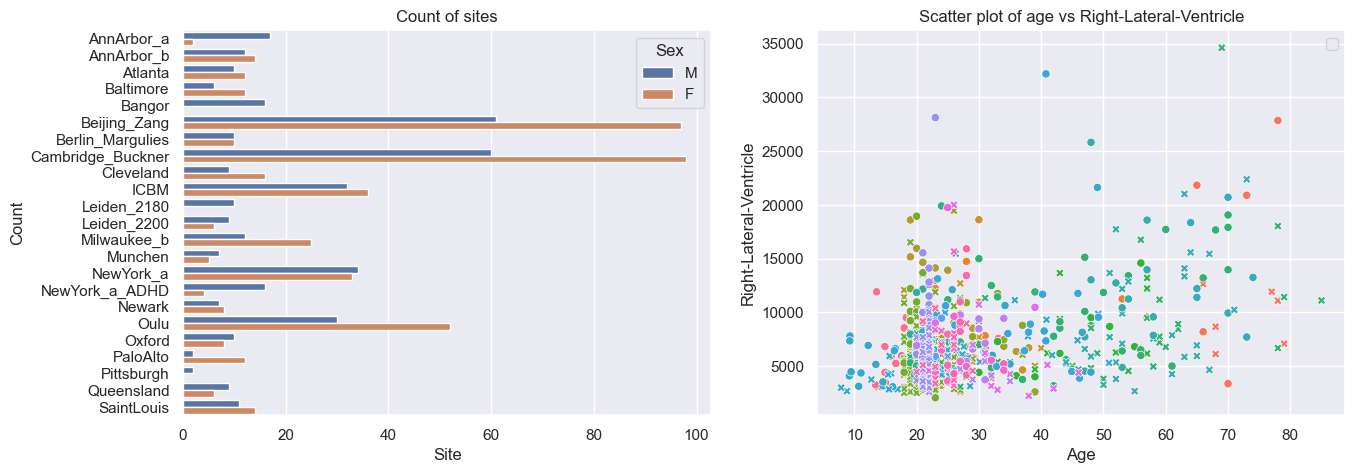

In [6]:
# Visualize the data
feature_to_plot = features_to_model[1]
df = train.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=df, y=("batch_effects", "site"), hue=("batch_effects", "sex"), ax=ax[0], orient="h")
ax[0].legend(title="Sex")
ax[0].set_title("Count of sites")
ax[0].set_xlabel("Site")
ax[0].set_ylabel("Count")


sns.scatterplot(
    data=df,
    x=("X", "age"),
    y=("Y", feature_to_plot),
    hue=("batch_effects", "site"),
    style=("batch_effects", "sex"),
    ax=ax[1],
)
ax[1].legend([], [])
ax[1].set_title(f"Scatter plot of age vs {feature_to_plot}")
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)

plt.show()

**What to look for in these plots:**

The count plot on the left shows how many subjects come from each site, split by sex. Notice the large imbalance — some sites have hundreds of subjects, others just a handful. This is exactly why partial pooling matters: a model that treats all sites equally will give noisy, unreliable estimates for the small sites.

The scatter plot on the right shows the raw age–feature relationship for WM-hypointensities. Notice the strong right skew (a few subjects have very high values) and the increasing spread with age (heteroskedasticity). Both of these will cause problems for a Gaussian normative model, as we will see shortly.

### Visualising heteroskedasticity

Before fitting any models, it is worth checking whether the variance of the response variable changes with age. If it does, we need σ to be a **function of age** rather than a constant — this is called **heteroskedasticity**.

The right-hand plot below shows the rolling standard deviation across age bins. An increasing trend means subjects at that age are more spread out around the mean — the model needs to capture this.

**Question:** For `Right-Lateral-Ventricle`, does variance increase or decrease with age? What does this imply about how the 5th and 95th centile bands should look?

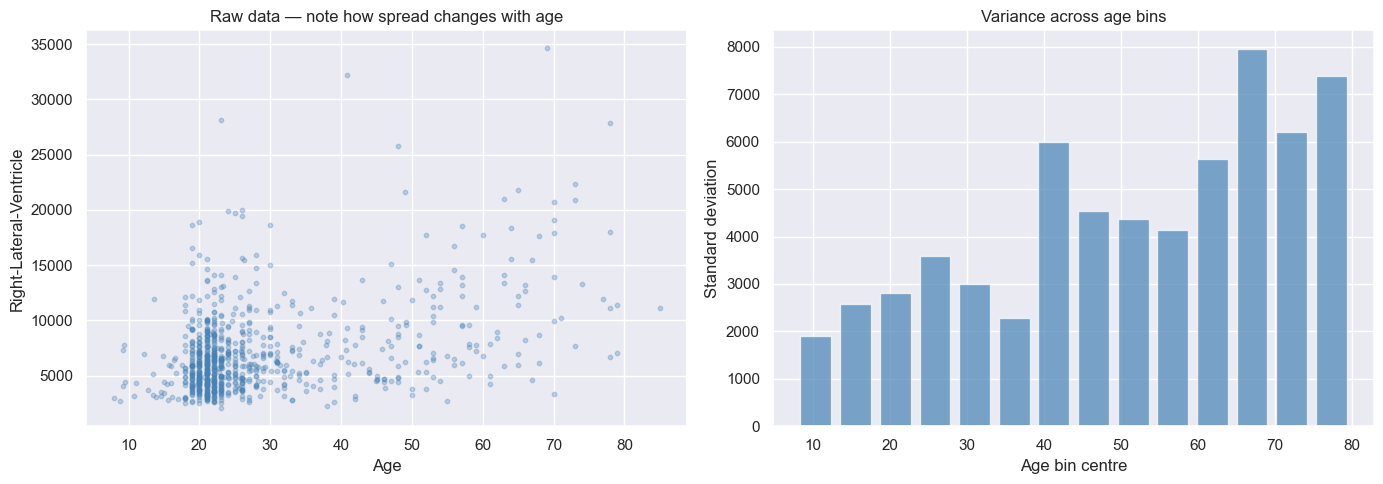

In [7]:
# Visualise heteroskedasticity explicitly before fitting
# We plot the raw data and overlay a rolling standard deviation to show
# how variance changes across the age range.

feature_to_examine = "Right-Lateral-Ventricle"
df_train = train.to_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw scatter
axes[0].scatter(
    df_train[("X", "age")],
    df_train[("Y", feature_to_examine)],
    alpha=0.3, s=10, color="steelblue"
)
axes[0].set_xlabel("Age")
axes[0].set_ylabel(feature_to_examine)
axes[0].set_title("Raw data — note how spread changes with age")

# Rolling std across age bins
age_bins = pd.cut(df_train[("X", "age")], bins=15)
rolling_std = df_train[("Y", feature_to_examine)].groupby(age_bins).std()
bin_centres = [(b.left + b.right) / 2 for b in rolling_std.index]
axes[1].bar(bin_centres, rolling_std.values, width=4, color="steelblue", alpha=0.7)
axes[1].set_xlabel("Age bin centre")
axes[1].set_ylabel("Standard deviation")
axes[1].set_title("Variance across age bins")

plt.tight_layout()
plt.show()

## Creating a Normative model

A normative model has a regression model for each response variable. We provide a template regression model which is copied for each response variable. 

A template regression model can be anything that extends the `RegressionModel`. We provide a number of built-in regression models, but you can also create your own. 

Here we use the `HBR` class, which implements a Hierarchical Bayesian Regression model. 


### Likelihoods

`HBR` models are composed of a likelihood and a number of priors on the parameters of the likelihood. The PCNtoolkit offers a number of likelihood functions:
1. NormallLikelihood: Good for modeling data that is (approximately) normally distributed.
2. SHASHbLikelihood: Good for modeling data that is heavily skewed, or tailed. 
3. BetaLikelihood: Good for modeling data that is bounded, e.g. between 0 and 1.

### Likelihood parameters

Each of these likelihoods takes their own set of parameters, and for each, we have to set a prior:
1. NormalLikelihood:
    - `mu`: The mean of the normal distribution.
    - `sigma`: The standard deviation of the normal distribution.
2. SHASHbLikelihood:
    - `mu`: The mean of the skew-normal distribution.
    - `sigma`: The standard deviation of the skew-normal distribution.
    - `epsilon`: The skewness parameter of the skew-normal distribution.
    - `delta`: The tail thickness (or kurtosis) of the skew-normal distribution.
3. BetaLikelihood:
    - `alpha`: The shape parameter of the beta distribution.
    - `beta`: The scale parameter of the beta distribution.

### Configuring likelihood parameters

Each likelihood parameter needs to be configured. The defaults should work reasonably well for most cases, at least where the data is standardized. Here's a quick guide to configuring the likelihood parameters yourself, using the `make_prior` function.

1. Is your parameter a function of the covariates? If so, you set the `linear` parameter to `True`.
   1. If so, you can choose the basis expansion to use for the parameter: BSplineBasisFunction, LinearBasisFunction, or PolynomialBasisFunction.
   2. Also, determine whether the slope and intercept of the prior have a random effect or not. Here's an example of a linear prior with a bspline basis expansion and a random effect in the intercept. 

```python
mu = make_prior(
    'mu', 
    linear=True, 
    basis_function = BSplineBasisFunction(degree=3, nknots=5), 
    intercept = make_prior('intercept_mu', random=True))
```

2. If your parameter is not a function of the covariates, you have to decide whether the parameter itself has a random effect or not. Here's an example of a prior with a random effect.

```python
epsilon = make_prior(
    'epsilon', 
    random=True)
```

3. Some parameters (such as sigma) need to be strictly positive, which we can enforce with a mapping. Here's an example of a prior with a mapping to the positive real line.

```python
# The mapping_params are (horizontal shift, scaling, vertical shift)
sigma = make_prior(
    'sigma', 
    mapping='softplus', 
    mapping_params=(0, 5, 0))
```

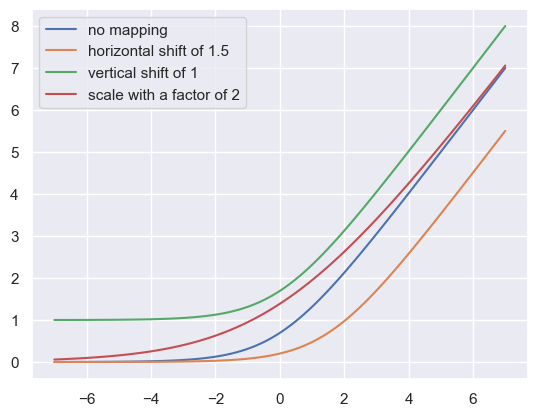

In [8]:
# Mini demo of the mapping params
xsp = np.linspace(-7, 7, 100)
softplus = lambda x: np.log(1 + np.exp(x))
paramaterized_softplus = lambda x, a, b, c: softplus((x - a) / b) * b + c
plt.plot(xsp, paramaterized_softplus(xsp, 0, 1, 0), label="no mapping")
plt.plot(xsp, paramaterized_softplus(xsp, 1.5, 1, 0), label="horizontal shift of 1.5")
plt.plot(xsp, paramaterized_softplus(xsp, 0, 1, 1), label="vertical shift of 1")
plt.plot(xsp, paramaterized_softplus(xsp, 0, 2, 0), label="scale with a factor of 2")
plt.legend()
plt.show()

4. Any non-linear parameters can be further configured with `dist_name` and `dist_params`. Here's an example of a prior with a gamma distribution. 

```python
alpha = make_prior('alpha', dist_name='gamma', dist_params=(1, 1))
```
We currently support the following distributions:
- Normal
- HalfNormal
- LogNormal
- Uniform
- Gamma
  
The order of the parameters is important, and follows the order of the parameters in the corresponding distributions in PyMC.

## Step 1 — No site effects (single shared intercept)

This is the simplest possible normative model. There are **no batch effects** at all — site and sex are completely ignored. Every subject, regardless of which scanner they were scanned on or their sex, shares a single intercept τ_μ. The only thing the model learns is how brain features change with age.

**How it works:** We create a separate `NormData` object with no batch effect columns. Because the HBR model only knows about batch effects through the `NormData` object, passing data with no batch effects means the intercept is a single scalar estimated from everyone together.

**What to expect in the outputs:**
- The QQ plots will show **banding by site** — subjects from the same scanner cluster together rather than being uniformly distributed along the diagonal. This is the signature of unmodelled scanner differences.
- For `WM-hypointensities`, the lower centile (5th percentile) will likely **dip below zero** — a biologically impossible value for a brain volume. This happens because the Gaussian likelihood assigns probability mass to negative values.

**Question for students:** Look at the QQ plot. Can you identify clusters of points that deviate together? These are likely subjects from the same scanning site.

In [9]:
# ── Step 1 setup: build NormData without batch effects ──────────────────────
# The key distinction from Step 2 is the NormData object, not the make_prior call.
# Without batch effect columns, the model has no knowledge that sites exist.

import pandas as pd

df_rebuild = pd.DataFrame({"age": train.X.values[:, 0]})
for feat in features_to_model:
    df_rebuild[feat] = train.Y.sel(response_vars=feat).values

train_no_be = NormData.from_dataframe(
    name="fcon1000_no_batch",
    dataframe=df_rebuild,
    covariates=["age"],
    batch_effects=[],          # no site, no sex
    response_vars=features_to_model,
)

df_rebuild_test = pd.DataFrame({"age": test.X.values[:, 0]})
for feat in features_to_model:
    df_rebuild_test[feat] = test.Y.sel(response_vars=feat).values

test_no_be = NormData.from_dataframe(
    name="fcon1000_no_batch_test",
    dataframe=df_rebuild_test,
    covariates=["age"],
    batch_effects=[],
    response_vars=features_to_model,
)

In [10]:
# ── Step 1 model: random=False + no batch effects = one shared τ_μ ───────────
mu_s1 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=False,
        dist_name="Normal",
        dist_params=(0.0, 1.0),  # one scalar, same for everyone
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_s1 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

s1_model = NormativeModel(
    template_regression_model=HBR(
        name="step1_no_sites",
        cores=4, progressbar=True, draws=1000, tune=500, chains=2,
        nuts_sampler="nutpie",
        likelihood=NormalLikelihood(mu_s1, sigma_s1),
    ),
    savemodel=True, 
    evaluate_model=True, 
    saveresults=True,
    saveplots=True, 
    save_dir="resources/step1_no_sites",
    inscaler="standardize", 
    outscaler="standardize",
)

test_s1 = test_no_be.copy()  # always copy before predicting
s1_model.fit_predict(train_no_be, test_s1)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.12,159
,1500,0,0.12,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,255
,1500,0,0.13,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.14,31
,1500,0,0.14,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.14,255
,1500,0,0.12,127


<xarray.NormData> Size: 103kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 1, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 0 1 2 3 4 ... 212 213 214 215
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U18 72B 'dummy_batch_effect'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) int64 2kB 0 1 2 3 4 ... 212 213 214 215
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U32 28kB '0.0' ... ...
    Z                  (observations, response_vars) float64 7kB 0.6172 ... 0...
    centiles           (centile, observations, response_vars) float64 35kB -5...
    baseline_logp      (observations, response_vars) float64 7kB -3.66 ... -0...
    logp               (observations, response_vars) float64 7kB -1.703 ... -...
    Yhat               (observations, response_vars) float64 7kB 1.821e+03 .....
    statistics         (response_vars, statistic) float64 416B 0.2816 ... 0.1589
Attributes:
    real_ids:                       False
    is_scaled:                      False
    name:                           fcon1000_no_batch_test
    unique_batch_effects:           {np.str_('dummy_batch_effect'): ['0.0']}
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 12.02, 'max': 77...
    batch_effect_covariate_ranges:  {np.str_('dummy_batch_effect'): {'0.0': {...

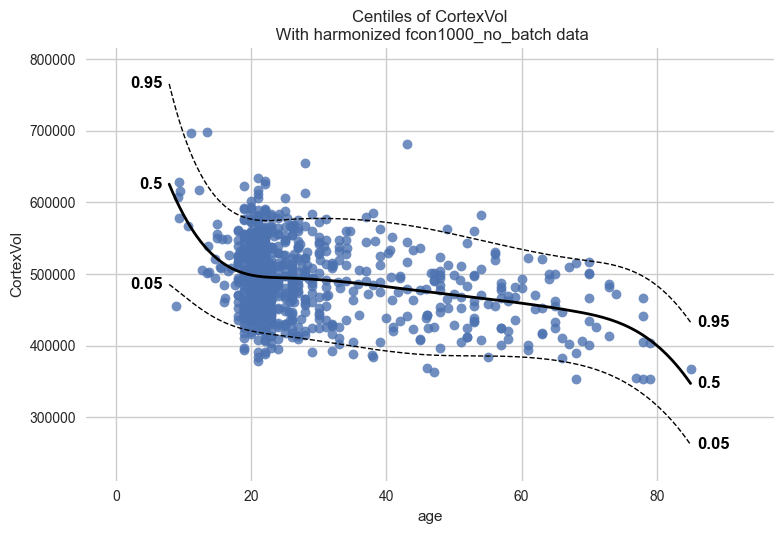

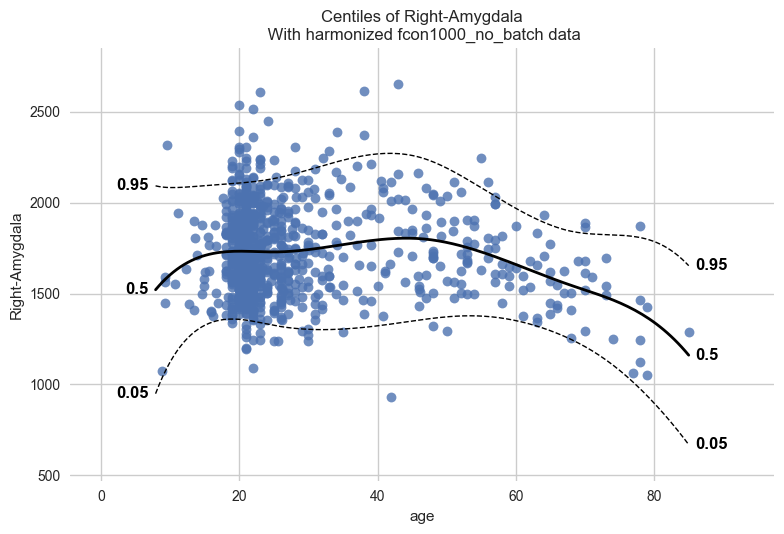

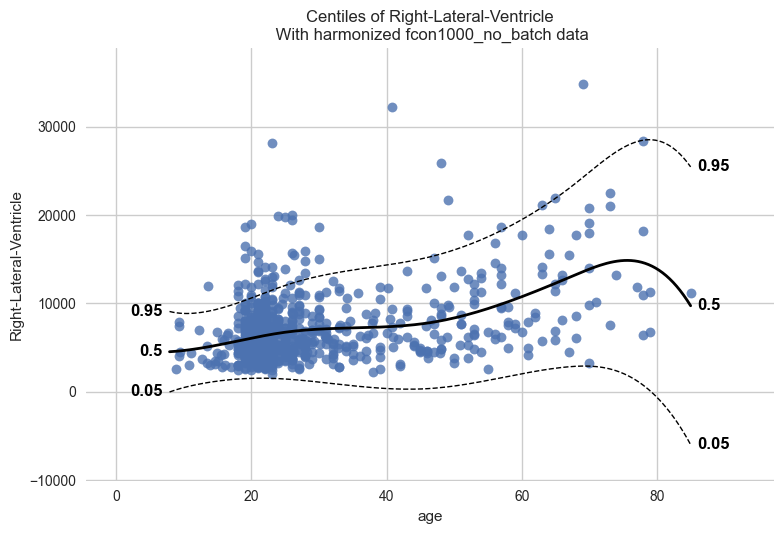

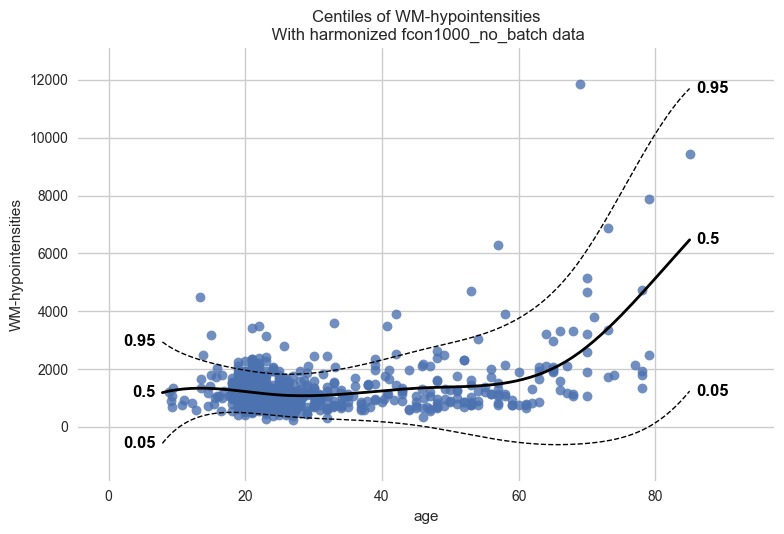

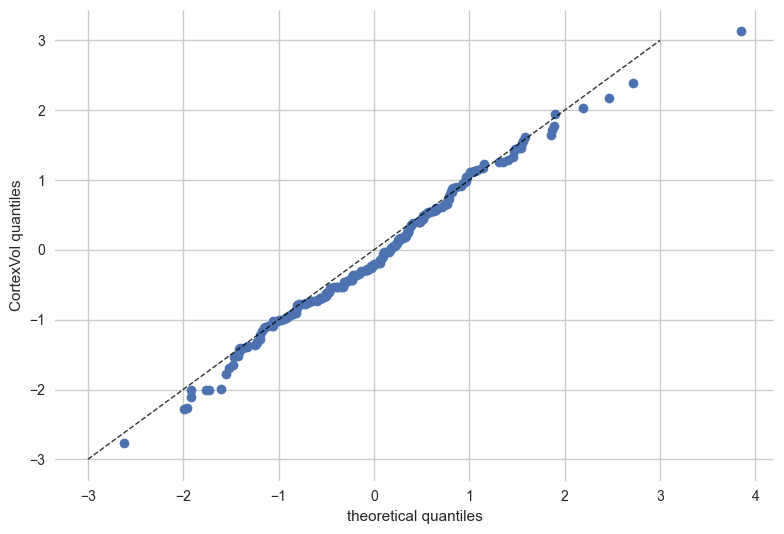

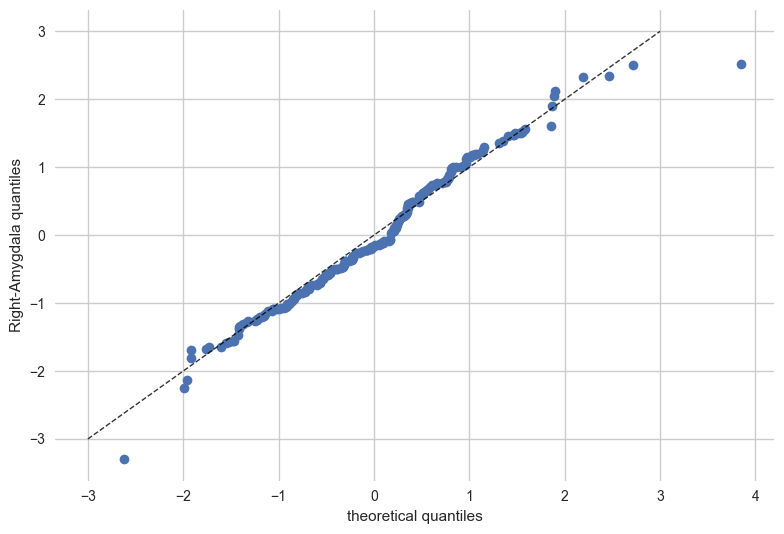

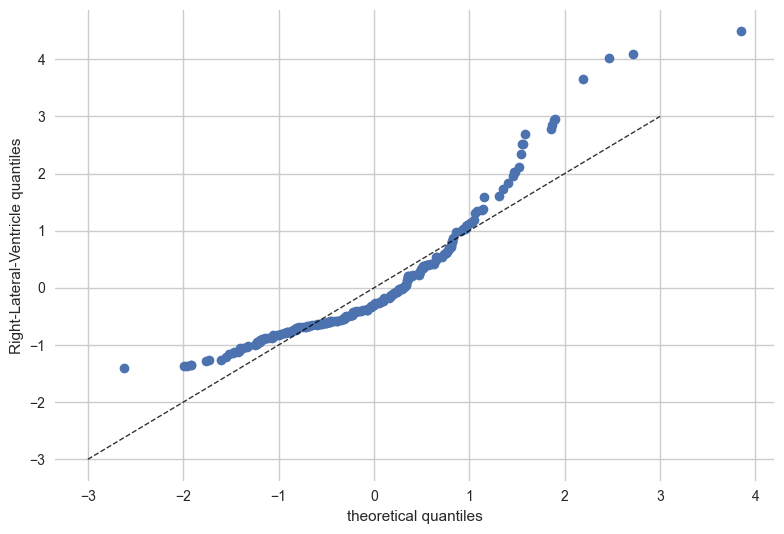

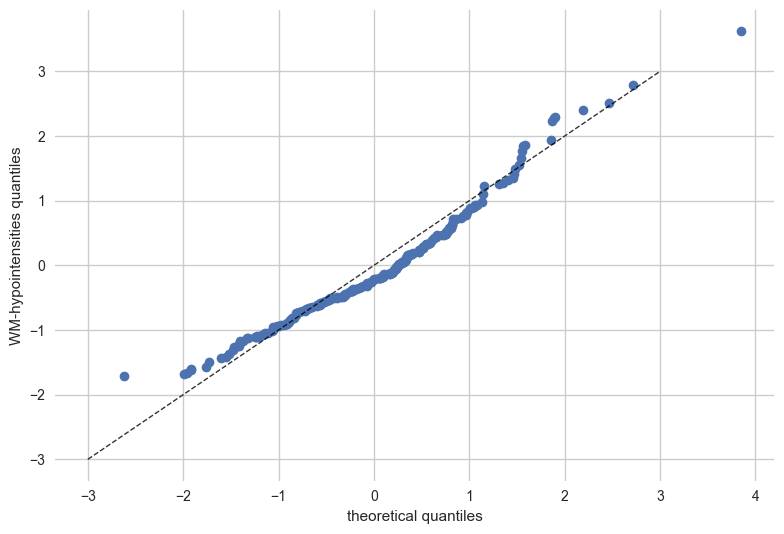

[<Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>]

In [30]:
# Inspect Step 1: look for site banding in the QQ plot
# and check whether WM-hypointensities centiles go below zero

plot_centiles_advanced(
    s1_model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=train_no_be,
    harmonize_data=True,
    show_legend=False,
    show_other_data=True
)

plot_qq(test_s1, plot_id_line=True)

## Step 2 — Fixed site effects (no pooling)

Now we introduce site and sex as batch effects, but model them as **fixed effects** — each site×sex combination gets its own intercept τ_b, estimated independently with no sharing of information across sites.

**How it differs from Step 1:** The `make_prior` call is *identical* — `random=False` in both cases. The only difference is that we now pass the original `train` NormData which has site and sex as batch effect columns. The HBR model sees these columns and creates one intercept per batch group automatically.

**No pooling** means the prior N(0, 1) on each τ_b was fixed by us before seeing any data — it is not learned from the data. A site with 3 subjects and a site with 500 subjects both estimate their intercept from their own data only. There is no mechanism for the large sites to help the small ones.

**What to expect:**
- The site banding in the QQ plot should largely **disappear** — each site now has its own offset
- Small sites may still show unusual patterns because their intercepts are estimated from very few subjects
- The lower centile for `WM-hypointensities` will still dip below zero — the Gaussian likelihood problem remains

**Question for students:** Compare the QQ plots from Step 1 and Step 2. Has the banding improved? What about the tails?

In [13]:
# ── Step 2 model: random=False + batch effects in NormData ───────────────────
# The make_prior code is the same as Step 1.
# The difference is that train (not train_no_be) is passed — it has site and sex.
# This gives B independent intercepts, one per site×sex combination.

mu_s2 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=False,
        dist_name="Normal",
        dist_params=(0.0, 1.0),  # B independent scalars, one per site×sex
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_s2 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

s2_model = NormativeModel(
    template_regression_model=HBR(
        name="step2_fixed_sites",
        cores=4, progressbar=True, draws=1000, tune=500, chains=2,
        nuts_sampler="nutpie",
        likelihood=NormalLikelihood(mu_s2, sigma_s2),
    ),
    savemodel=True, 
    evaluate_model=True, 
    saveresults=True,
    saveplots=True, 
    save_dir="resources/step2_fixed_sites",
    inscaler="standardize", 
    outscaler="standardize",
)

test_s2 = test.copy()  # always copy before predicting
train_s2 = train.copy()  # always copy before fitting
s2_model.fit_predict(train_s2, test_s2)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.11,63
,1500,0,0.11,31


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.15,255
,1500,0,0.12,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,127
,1500,0,0.14,191


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.14,255
,1500,0,0.14,127


<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.6168 ... 0...
    centiles           (centile, observations, response_vars) float64 35kB -5...
    baseline_logp      (observations, response_vars) float64 7kB -3.66 ... -0...
    logp               (observations, response_vars) float64 7kB -1.702 ... -...
    Yhat               (observations, response_vars) float64 7kB 1.822e+03 .....
    statistics         (response_vars, statistic) float64 416B 0.28 ... 0.1588
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

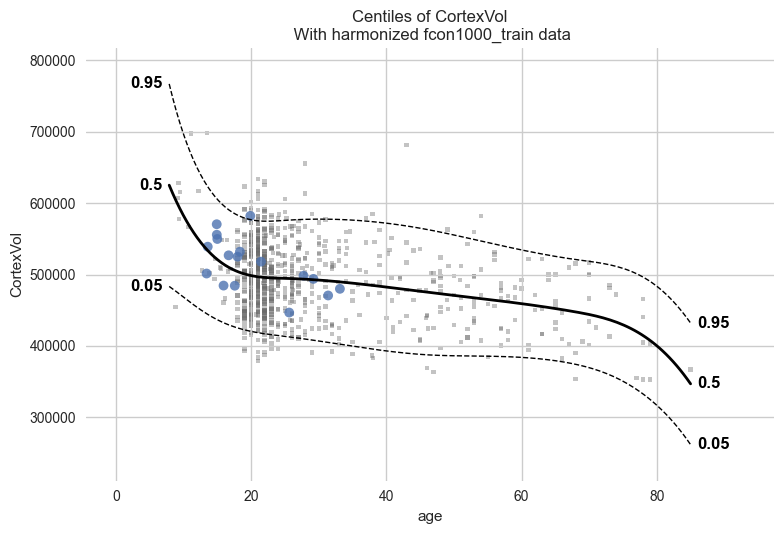

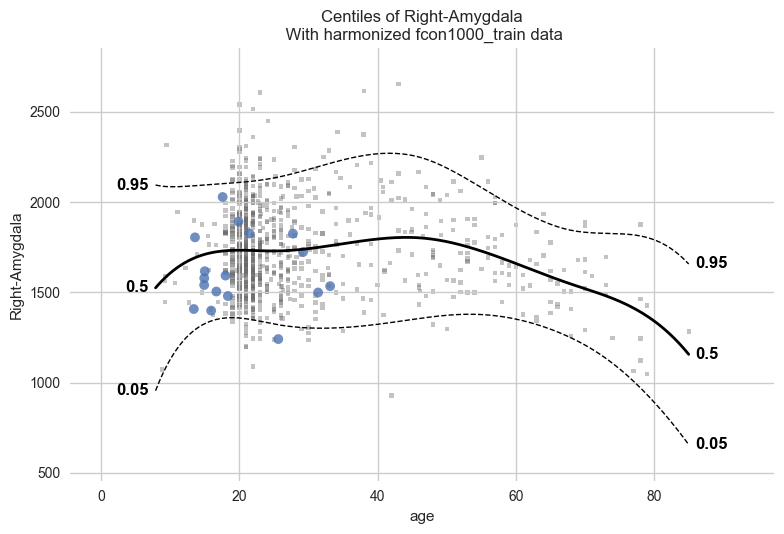

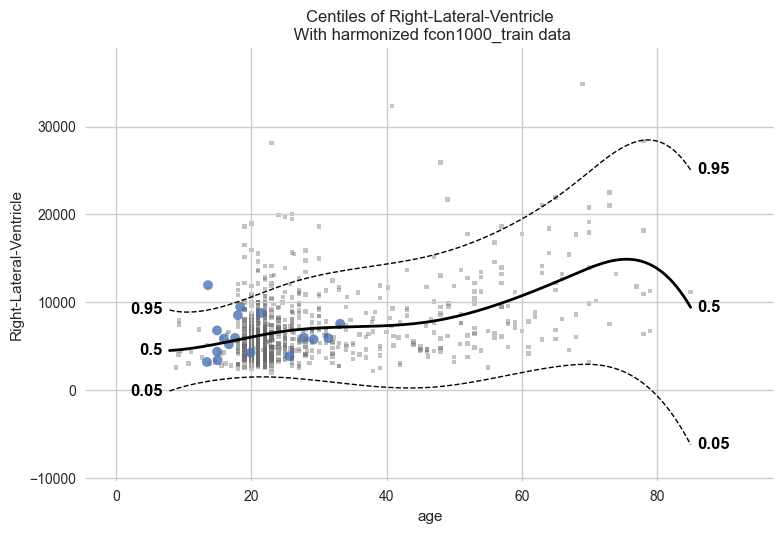

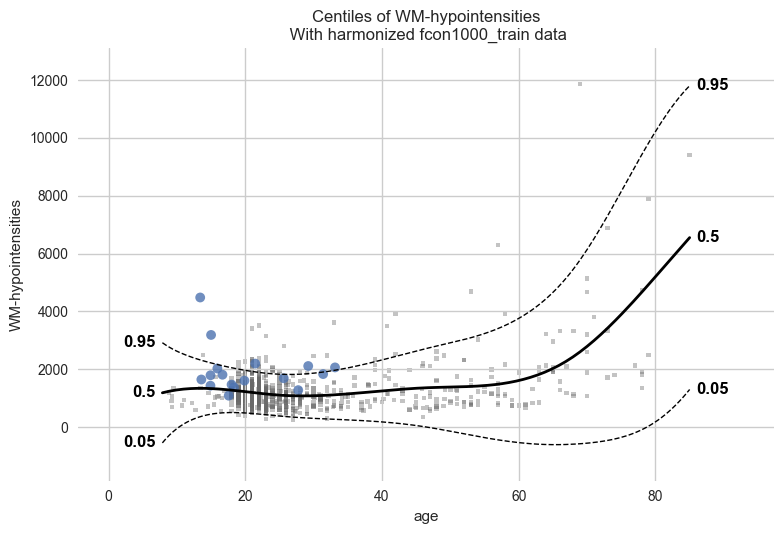

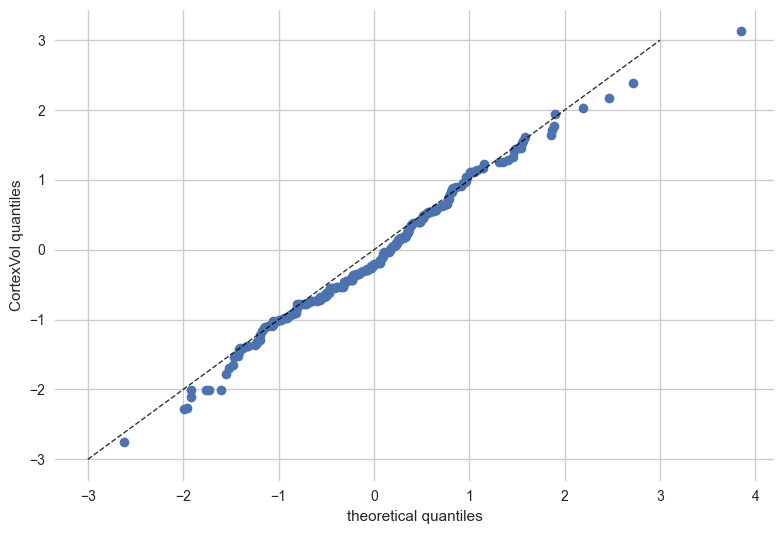

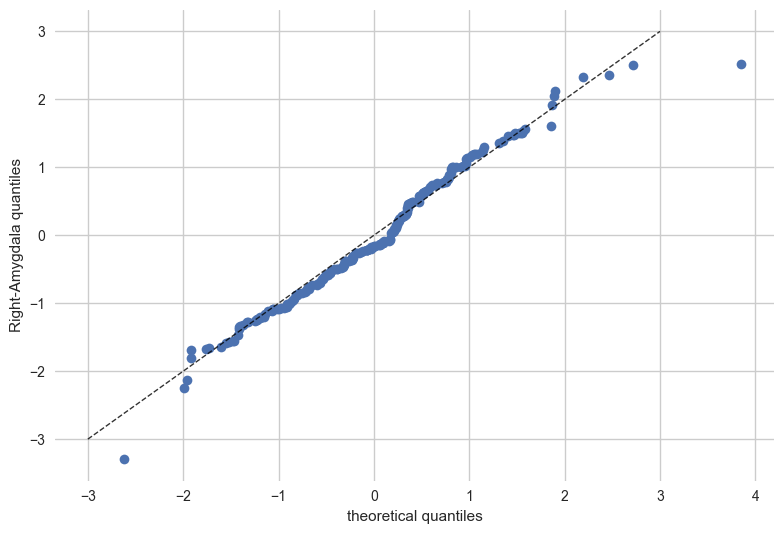

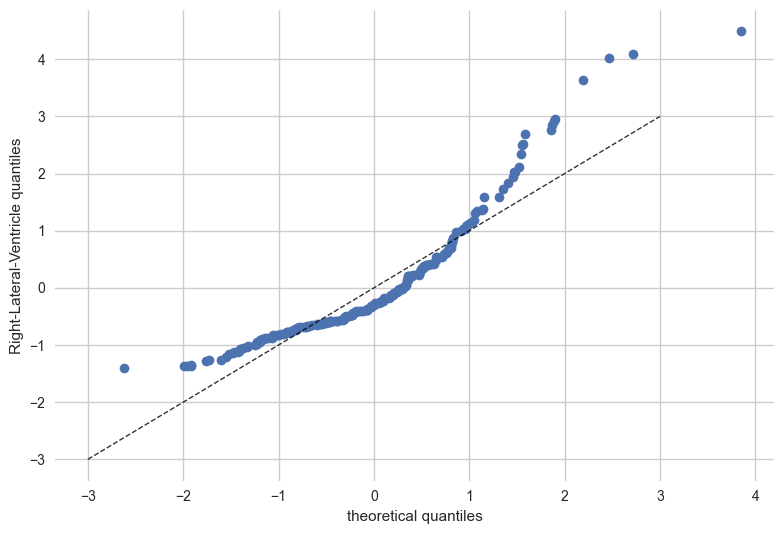

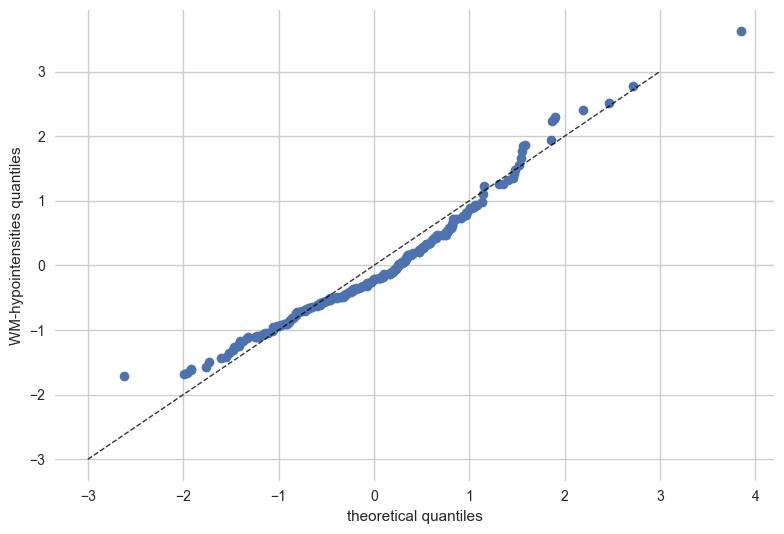

[<Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>]

In [29]:
# Inspect Step 2: site banding should be reduced compared to Step 1

plot_centiles_advanced(
    s2_model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=train_s2,
    harmonize_data=True,
    show_legend=False,
    show_other_data=True
)

plot_qq(test_s2, plot_id_line=True)

## Step 3 — Random site effects (HBR Gaussian)

Now we add the key ingredient of Hierarchical Bayesian Regression: a shared group distribution over site intercepts. Each τ_b is no longer estimated independently — instead it is drawn from Normal(μ_τ, σ_τ), where μ_τ and σ_τ are learned from all sites together. Small sites are regularised toward the group mean (shrinkage); large sites deviate freely.

**What changes from Step 2:** `random=True` on the intercept. Two new hyperprior nodes μ_τ and σ_τ appear above the batch plate.

**What to expect:** The QQ plots should look similar to Step 2 but with better-behaved estimates for small sites. The lower centile for WM-hypointensities still dips below zero — fixing that requires the SHASH likelihood in Step 4.

**Question:** Compare the intercept estimates for the smallest site across Step 2 and Step 3. Which is more stable?

**Question to consider:** Look at the features we selected — `WM-hypointensities`, `Right-Lateral-Ventricle`, `Right-Amygdala`, `CortexVol`. Which of these do you expect to be most non-Gaussian, and why?

In [15]:
# Step 3: Gaussian HBR — the simplest possible model
# mu is linear in age with a random (site-specific) intercept
# sigma is linear in age, shared across sites
# No skewness or kurtosis parameters

mu_gauss = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0),
                         mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_gauss = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

gaussian_regression_model = HBR(
    name="gaussian_template",
    cores=4,
    progressbar=True,
    draws=1000,
    tune=500,
    chains=2,
    nuts_sampler="nutpie",
    likelihood=NormalLikelihood(mu_gauss, sigma_gauss),
)

gaussian_model = NormativeModel(
    template_regression_model=gaussian_regression_model,
    savemodel=True,
    evaluate_model=True,
    saveresults=True,
    saveplots=True,
    save_dir="resources/step3_gaussian",
    inscaler="standardize",
    outscaler="standardize",
)


test_s3 = test.copy()
train_s3 = train.copy()
gaussian_model.fit_predict(train_s3, test_s3)



c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.12,223
,1500,0,0.11,95


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.14,31
,1500,0,0.15,127


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.12,31
,1500,0,0.14,255


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.13,31
,1500,0,0.13,31


<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.5662 ... -...
    centiles           (centile, observations, response_vars) float64 35kB -5...
    baseline_logp      (observations, response_vars) float64 7kB -3.66 ... -0...
    logp               (observations, response_vars) float64 7kB -1.716 ... -...
    Yhat               (observations, response_vars) float64 7kB 1.889e+03 .....
    statistics         (response_vars, statistic) float64 416B 0.3588 ... 0.1014
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

In [ ]:
# Exercise: Inspect the test_s3 object. Extract the zscores to a variable called zscores.

=== Centile curves (Gaussian model) ===


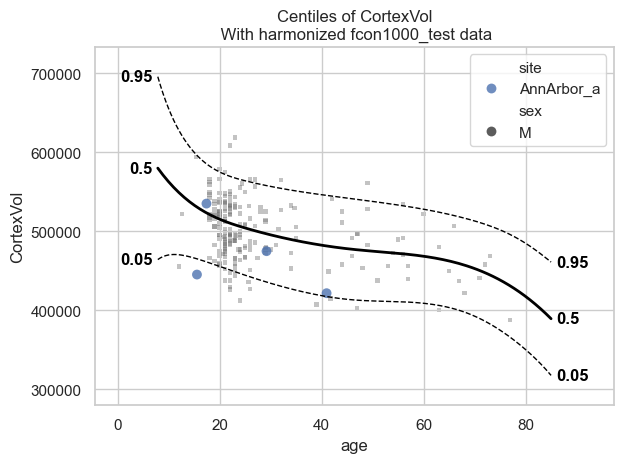

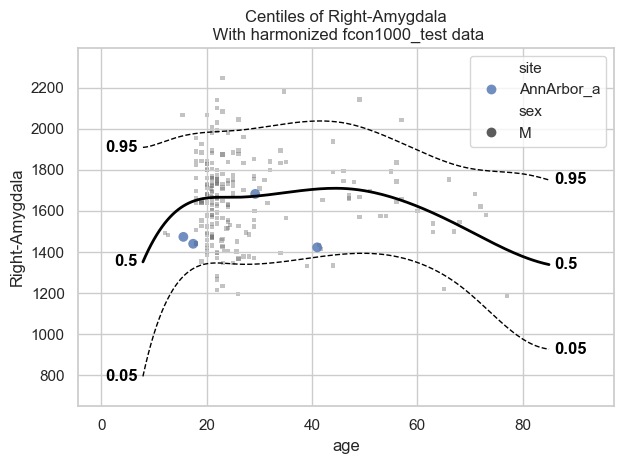

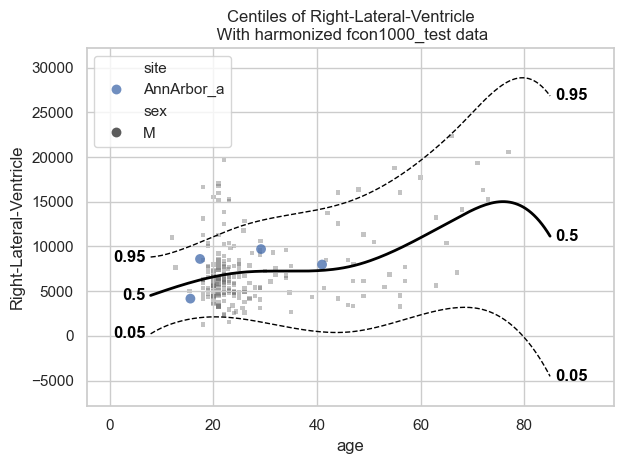

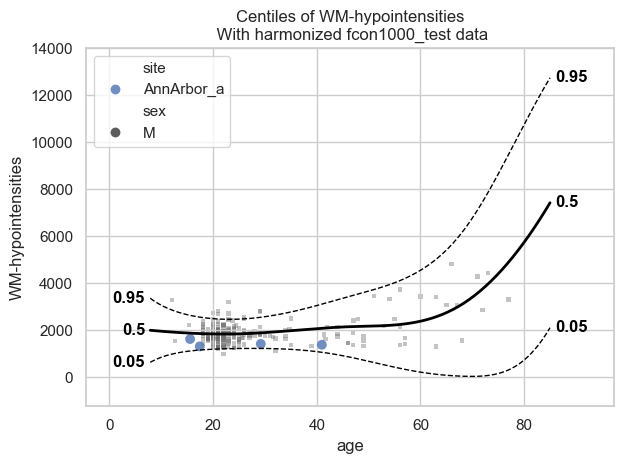


=== QQ plots (Gaussian model) ===


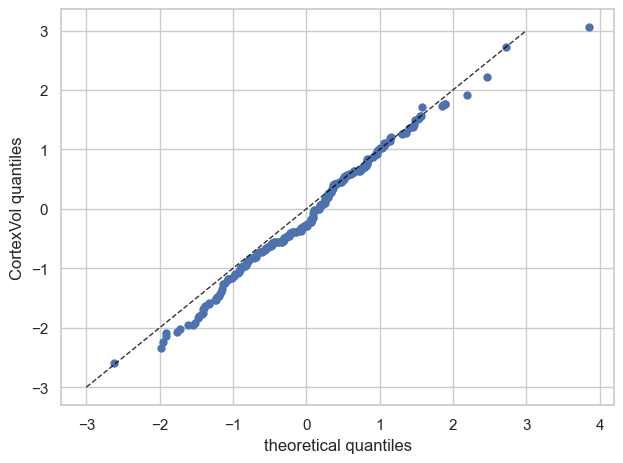

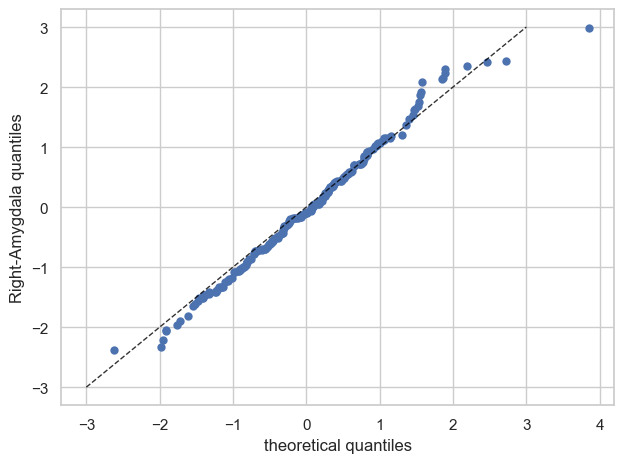

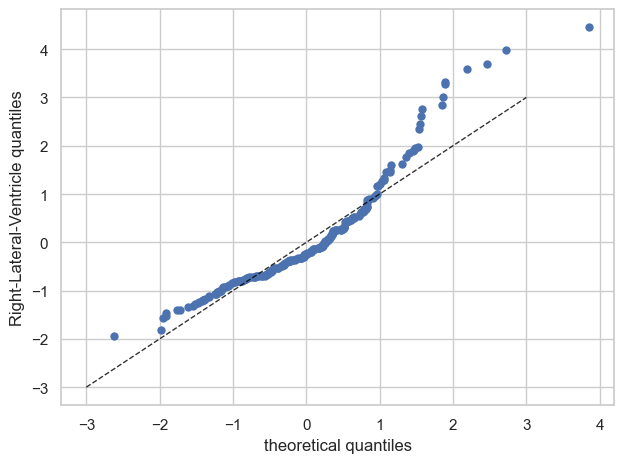

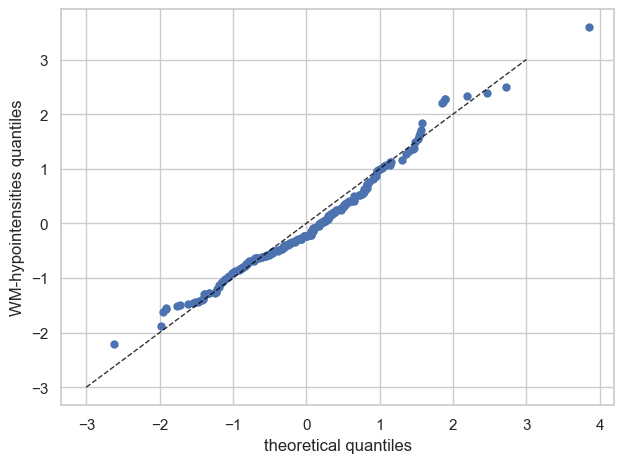

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [16]:
# Inspect the Gaussian fit: centile curves and QQ plots
# Pay attention to how well the curves track the data for each feature.
# WM-hypointensities in particular should look bad.

print("=== Centile curves (Gaussian model) ===")
plot_centiles_advanced(
    gaussian_model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=test_s3,
    show_other_data=True,
    harmonize=True
)

print("\n=== QQ plots (Gaussian model) ===")
plot_qq(test_s3, plot_id_line=True)

Look at the centile plots and QQ plots. Do you think the fit is good? 
Why? Why not?

In [17]:
# Print the moment statistics for the Gaussian model
# Skew and excess kurtosis of z-scores should be close to 0 for a good fit.
# Values far from 0 indicate the model is not capturing the data distribution.

print("Training set statistics (Gaussian):")
display(train_s3.get_statistics_df())
print("\nTest set statistics (Gaussian):")
display(test_s3.get_statistics_df())

Training set statistics (Gaussian):


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
CortexVol,0.519571,0.479763,0.091302,0.057264,1.069379,-0.349559,0.519571,36137.837582,0.710416,2.396717e-133,0.480429,0.995841,0.130728
Right-Amygdala,0.387544,0.538427,0.095027,0.087514,1.187940,-0.230999,0.387543,191.735838,0.604433,5.563724e-87,0.612457,0.990704,0.381786
Right-Lateral-Ventricle,0.241080,6.400425,0.101638,0.379965,1.234067,-0.184871,0.241080,3354.157013,0.387932,2.428109e-32,0.758920,0.871648,1.876377
WM-hypointensities,0.359430,5.705719,0.083389,0.306735,0.869504,-0.549435,0.359429,653.657554,0.506432,2.433277e-57,0.640571,0.881821,1.774508



Test set statistics (Gaussian):


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
CortexVol,0.420911,-0.053010,0.176482,0.063544,1.103345,-0.252582,0.412731,37514.612983,0.642914,1.389092e-26,0.587269,0.994646,0.101446
Right-Amygdala,0.291004,-0.048074,0.151350,0.094820,1.227161,-0.154108,0.290094,198.795419,0.503649,2.706827e-15,0.709906,0.991569,0.210688
Right-Lateral-Ventricle,0.204413,2.669281,0.173463,0.421278,1.349185,-0.085436,0.203606,3490.278633,0.265218,7.940727e-05,0.796394,0.890313,1.459800
WM-hypointensities,0.358845,1.135413,0.160835,0.341981,0.798559,-0.320710,0.355830,485.760314,0.492279,1.386028e-14,0.644170,0.967506,0.749896


**What to look for:** For `WM-hypointensities` and `Right-Lateral-Ventricle`, you should see:
- Centile curves that dip below zero (impossible for a volume measure)
- QQ plots with curved tails — the empirical quantiles deviate from the theoretical Gaussian line
- Large skew and excess kurtosis values in the statistics table

This motivates the SHASH extension. Keep these plots open as a reference.

## Step 4 — SHASHb S_b1 (non-Gaussian likelihood)

Now we swap the Gaussian likelihood for `SHASHbLikelihood`, but keep **all four parameters as simple constants** — no age-dependence, no site effects on ε or δ. The only new thing is the SHASH distribution itself.

This isolates the effect of allowing skewness (ε) and tail thickness (δ) — we want to see how much improvement we get just from using a more flexible distribution, before adding any further complexity.

**Question:** The model samples a single ε and a single δ for the whole dataset. What does this assume about skewness across sites and across the lifespan?

In [18]:
# Step 4: SHASHb S_b1 — hierarchical μ, heteroskedastic σ, scalar ε and δ
# mu and sigma have the same full hierarchical structure as Step 3.
# The only change is the likelihood: Normal → SHASHb, with two new scalar priors.

mu_s4 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
        sigma=make_prior(dist_name="Normal", dist_params=(0.0, 1.0),
                         mapping="softplus", mapping_params=(0.0, 3.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma_s4 = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

# ε and δ: new scalar shape parameters — one value for the entire dataset (S_b1)
epsilon_s4 = make_prior(
    dist_name="Normal",
    dist_params=(0.0, 1.0),   # centred at 0 = no assumed skew direction
)
delta_s4 = make_prior(
    dist_name="Normal",
    dist_params=(1.0, 1.0),
    mapping="softplus",
    mapping_params=(0.0, 3.0, 0.6),  # floor at 0.6 for numerical stability
)

shashb1_regression_model = HBR(
    name="shashb1_template",
    cores=4, progressbar=True, 
    draws=1000, 
    tune=500, 
    chains=2,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu_s4, sigma_s4, epsilon_s4, delta_s4),
)

# 'model' is the canonical variable name — Step 5 comparison references it
model = NormativeModel(
    template_regression_model=shashb1_regression_model,
    savemodel=True, 
    evaluate_model=True, 
    saveresults=True,
    saveplots=True, 
    save_dir="resources/step4_shashb1",
    inscaler="standardize", 
    outscaler="standardize",
)

test_s4 = test.copy()  # always copy before predicting
train_s4 = train.copy()  # always copy before fitting
model.fit_predict(train_s4, test_s4)    

Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,1023
,1500,0,0.01,1023


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,1023
,1500,0,0.01,1023


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.01,1023
,1500,0,0.02,255


Progress,Draws,Divergences,Step Size,Gradients/Draw
,1500,0,0.02,511
,1500,0,0.02,511


<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.52 ... -1.144
    centiles           (centile, observations, response_vars) float64 35kB 1....
    baseline_logp      (observations, response_vars) float64 7kB -3.66 ... -0...
    logp               (observations, response_vars) float64 7kB -1.619 ... -...
    Yhat               (observations, response_vars) float64 7kB 2.365e+03 .....
    statistics         (response_vars, statistic) float64 416B 0.3925 ... -0....
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

=== Centile curves (SHASHb, constant ε and δ) ===


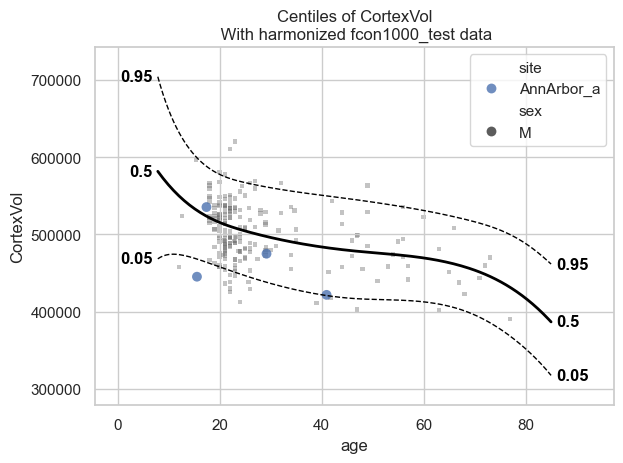

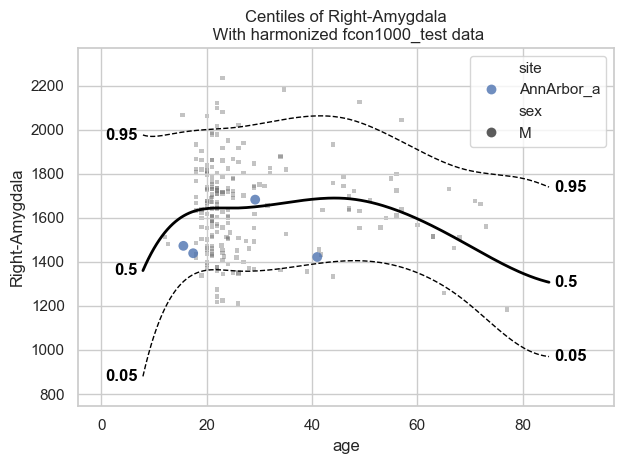

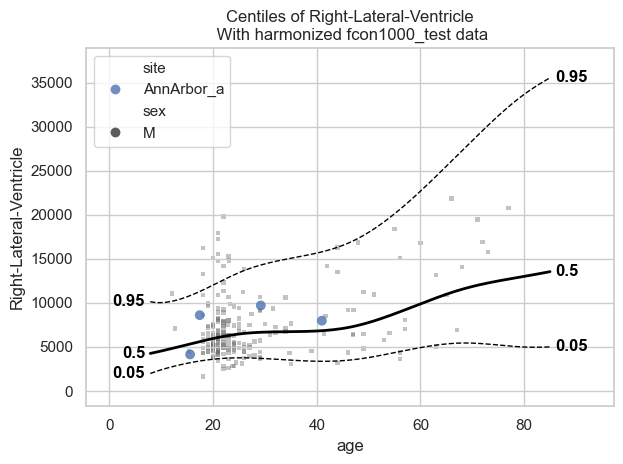

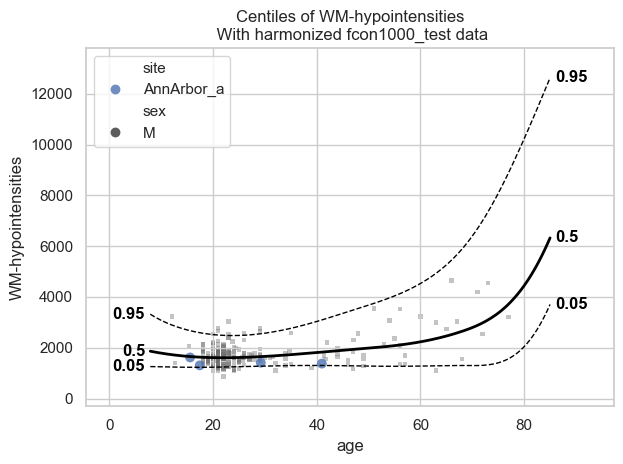


=== QQ plots (SHASHb, constant ε and δ) ===


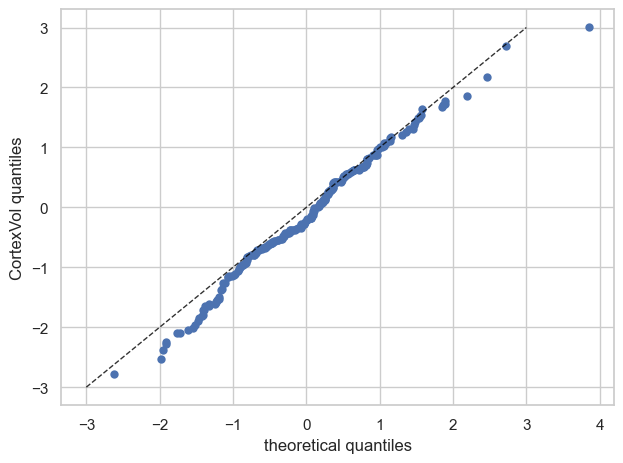

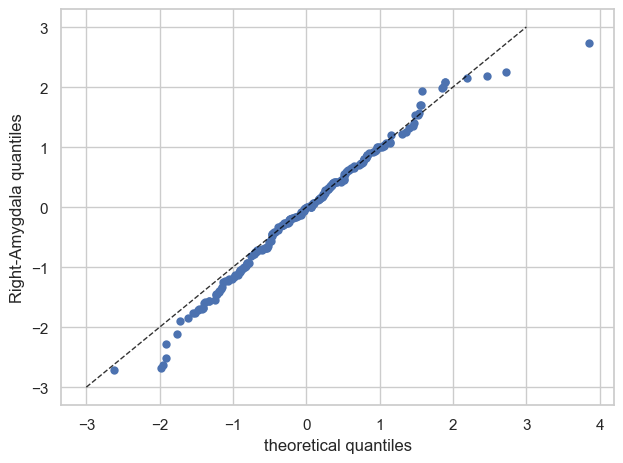

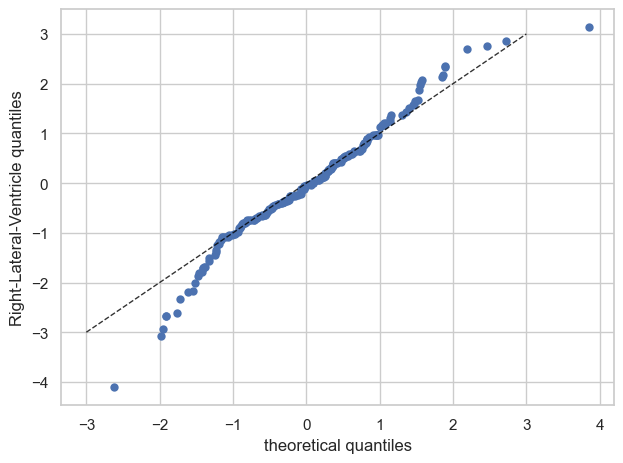

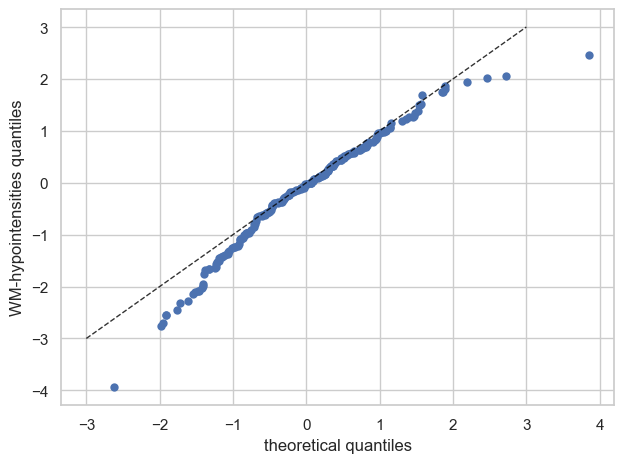


Test set statistics (SHASHb constant):


statistic,EXPV,Kurtosis,MACE,MAPE,MLL,MSLL,R2,RMSE,Rho,Rho_p,SMSE,ShapiroW,Skewness
response_vars,,,,,,,,,,,,,
CortexVol,0.422096,0.046001,0.174810,0.063417,1.104627,-0.251300,0.413239,37498.373577,0.641287,2.036996e-26,0.586761,0.995065,-0.017108
Right-Amygdala,0.301955,-0.017899,0.157421,0.094727,1.219617,-0.161652,0.300159,197.381144,0.525995,9.101326e-17,0.699841,0.991751,-0.122793
Right-Lateral-Ventricle,0.225780,1.107765,0.176226,0.431035,1.162094,-0.272527,0.225692,3441.540512,0.261031,1.037674e-04,0.774308,0.984803,-0.141277
WM-hypointensities,0.392505,0.455123,0.180117,0.347536,0.747923,-0.371346,0.383702,475.135324,0.512802,6.949543e-16,0.616298,0.980944,-0.495027


In [19]:
# Compare centile curves and QQ plots with the Gaussian model
# The SHASH centiles should now stay positive for volume measures.

print("=== Centile curves (SHASHb, constant ε and δ) ===")
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],
    scatter_data=test_s4,
    harmonize=True,
    show_other_data=True
)

print("\n=== QQ plots (SHASHb, constant ε and δ) ===")
plot_qq(test_s4, plot_id_line=True)

print("\nTest set statistics (SHASHb constant):")
display(test_s4.get_statistics_df())

**What to look for:**
- The lower centile for `WM-hypointensities` should no longer dip below zero
- QQ plots should be straighter than the Gaussian model
- Skew and excess kurtosis in the statistics table should be closer to 0

The fitted ε and δ values are available in the model trace. A positive ε means right skew; δ < 1 means heavier tails than Gaussian.

## Step 5 — Structured comparison across models

Now that we have both the Gaussian and S_b1 models fitted, let's compare them systematically using the same metrics as in the paper (Table 3).

| Metric | What it measures | Better when |
|---|---|---|
| `R²` | How much variance in Y the model explains — 1.0 means perfect prediction, 0 means the model does no better than predicting the mean | Higher — closer to 1 |
| `RMSE` | Root mean squared error — the average size of prediction errors in the original units of Y | Lower — closer to 0 |
| `ShapiroW` | Shapiro–Wilk test statistic — measures how close the Z-score distribution is to a standard Normal. W=1 is perfectly Gaussian | Higher — closer to 1 |
| `Skewness` | Asymmetry of the Z-score distribution — positive means a long right tail, negative means a long left tail. A well-calibrated model should produce Z-scores with no systematic skew | Closer to 0 |
| `Excess kurtosis` | How heavy the tails of the Z-score distribution are relative to a Gaussian — positive means more extreme outliers than expected, negative means fewer | Closer to 0 |

In [20]:
# Side-by-side statistics comparison for all 4 models.
# Skew and kurtosis of Z-scores should be closer to 0 for the SHASH model.

from scipy import stats
import pandas as pd

rows = []
for label, m, t in [
    ("Step 1 — Gaussian without batch effects", s1_model, test_s1),
    ("Step 2 — Gaussian with batch effects", s2_model, test_s2),
    ("Step 3 — Gaussian HBR", gaussian_model, test_s3),
    ("Step 4 — SHASHb S_b1", model, test_s4),
]:
    stats_df = t.get_statistics_df()
    z_df = t.to_dataframe()["Z"]
    skew = z_df.apply(stats.skew).rename("Skew")
    kurt = z_df.apply(stats.kurtosis).rename("ExKurtosis")
    combined = pd.concat([stats_df[["R2", "RMSE", "ShapiroW"]], skew, kurt], axis=1)
    combined.index = pd.MultiIndex.from_tuples([(label, f) for f in combined.index])
    rows.append(combined)

display(pd.concat(rows))

R2  \
Step 1 — Gaussian without batch effects CortexVol                0.061891   
                                        Right-Amygdala           0.023890   
                                        Right-Lateral-Ventricle  0.204005   
                                        WM-hypointensities       0.277511   
Step 2 — Gaussian with batch effects    CortexVol                0.061963   
                                        Right-Amygdala           0.024045   
                                        Right-Lateral-Ventricle  0.204422   
                                        WM-hypointensities       0.275813   
Step 3 — Gaussian HBR                   CortexVol                0.412731   
                                        Right-Amygdala           0.290094   
                                        Right-Lateral-Ventricle  0.203606   
                                        WM-hypointensities       0.355830   
Step 4 — SHASHb S_b1                    CortexVol                0.413239   
                                        Right-Amygdala           0.300159   
                                        Right-Lateral-Ventricle  0.225692   
                                        WM-hypointensities       0.383702   

                                                                         RMSE  \
Step 1 — Gaussian without batch effects CortexVol                47414.212030   
                                        Right-Amygdala             233.106993   
                                        Right-Lateral-Ventricle   3489.403213   
                                        WM-hypointensities         514.443242   
Step 2 — Gaussian with batch effects    CortexVol                47412.373272   
                                        Right-Amygdala             233.088464   
                                        Right-Lateral-Ventricle   3488.490064   
                                        WM-hypointensities         515.047411   
Step 3 — Gaussian HBR                   CortexVol                37514.612983   
                                        Right-Amygdala             198.795419   
                                        Right-Lateral-Ventricle   3490.278633   
                                        WM-hypointensities         485.760314   
Step 4 — SHASHb S_b1                    CortexVol                37498.373577   
                                        Right-Amygdala             197.381144   
                                        Right-Lateral-Ventricle   3441.540512   
                                        WM-hypointensities         475.135324   

                                                                 ShapiroW  \
Step 1 — Gaussian without batch effects CortexVol                0.996784   
                                        Right-Amygdala           0.991680   
                                        Right-Lateral-Ventricle  0.859548   
                                        WM-hypointensities       0.949902   
Step 2 — Gaussian with batch effects    CortexVol                0.996736   
                                        Right-Amygdala           0.991648   
                                        Right-Lateral-Ventricle  0.859656   
                                        WM-hypointensities       0.949670   
Step 3 — Gaussian HBR                   CortexVol                0.994646   
                                        Right-Amygdala           0.991569   
                                        Right-Lateral-Ventricle  0.890313   
                                        WM-hypointensities       0.967506   
Step 4 — SHASHb S_b1                    CortexVol                0.995065   
                                        Right-Amygdala           0.991751   
                                        Right-Lateral-Ventricle  0.984803   
                                        WM-hypointensities       0.980944   

                                                                     Skew

Gaussian: ['centiles_CortexVol_fcon1000_train_harmonized.png', 'centiles_Right-Amygdala_fcon1000_train_harmonized.png', 'centiles_Right-Lateral-Ventricle_fcon1000_train_harmonized.png', 'centiles_WM-hypointensities_fcon1000_train_harmonized.png']
SHASHb S_b1: ['centiles_CortexVol_fcon1000_train_harmonized.png', 'centiles_Right-Amygdala_fcon1000_train_harmonized.png', 'centiles_Right-Lateral-Ventricle_fcon1000_train_harmonized.png', 'centiles_WM-hypointensities_fcon1000_train_harmonized.png']


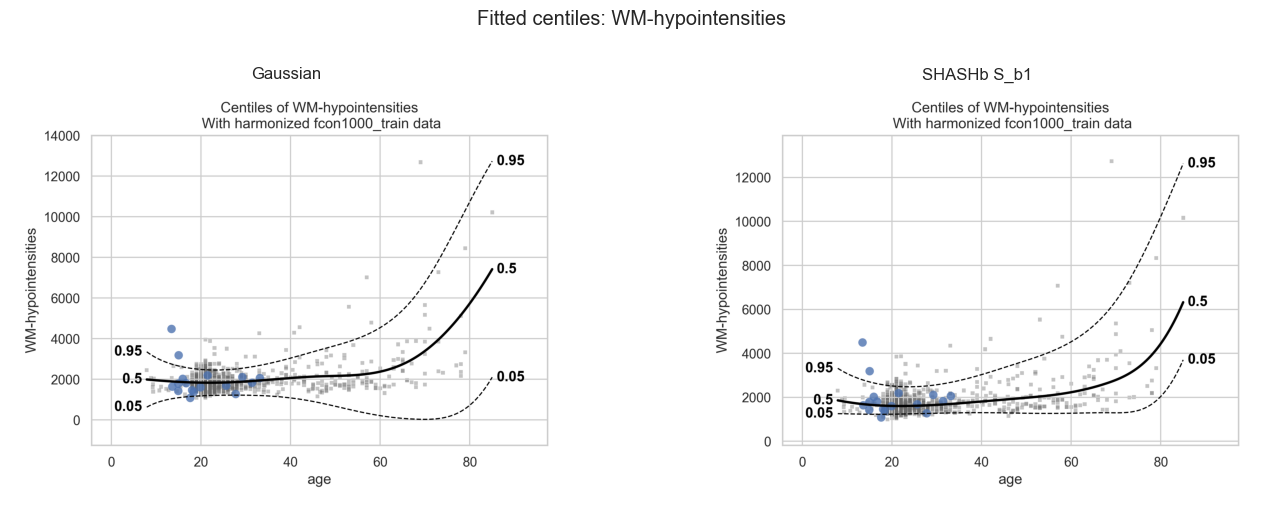

In [36]:
# Side-by-side centile curves for Gaussian (Step 3) vs SHASHb S_b1 (Step 4) model.
# This Figure is further explained in the paper accompanying this tutorial.

import os
import matplotlib.pyplot as plt

feature_to_compare = "WM-hypointensities"

for model_obj, title in [(gaussian_model, "Gaussian"), (model, "SHASHb S_b1")]:
    save_path = f"/tmp/centile_plots/{title}"
    os.makedirs(save_path, exist_ok=True)

# display side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, title in zip(axes, ["Gaussian", "SHASHb S_b1"]):
    folder = f"/tmp/centile_plots/{title}"
    files = os.listdir(folder)
    print(f"{title}: {files}")  # check filenames
    saved = [f for f in files if feature_to_compare in f]
    if saved:
        img = plt.imread(os.path.join(folder, saved[0]))
        ax.imshow(img)
    ax.set_title(title)
    ax.axis("off")

plt.suptitle(f"Fitted centiles: {feature_to_compare}", y=1.02)
plt.tight_layout()
plt.show()

**Questions for reflection:**

1. For which features does the SHASH model improve the most over Gaussian? For which features is the improvement smallest?
2. Does the lower centile (5th percentile) stay positive for volume measures? This is a basic sanity check.
3. Look at the skew and kurtosis statistics. Which model gets closer to 0? Is the improvement larger for "hard" or "easy" phenotypes?


## Advanced: Plot the results

The PCNtoolkit offers are a number of different plotting functions:
1. plot_centiles: Plot the predicted centiles for a model on top of harmonized scatter data. 
2. plot_centiles_advanced: a more advanced version of plot_centiles, with more configuration options, coloring, and conditionals
3. plot_qq: Plot the QQ-plot of the predicted Z-scores
4. plot_ridge: Plot density plots of the predicted Z-scores

Let's start with the centiles.

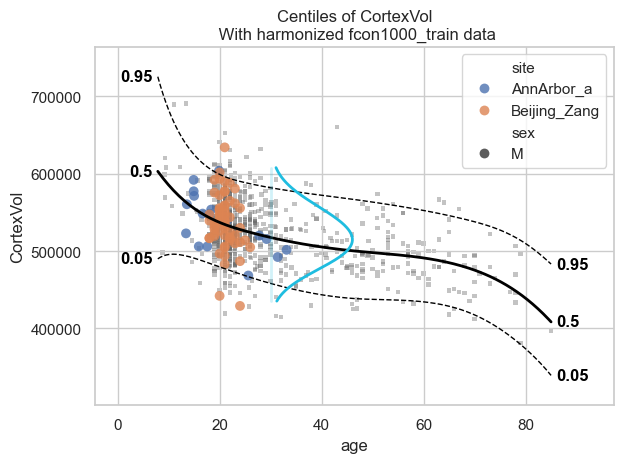

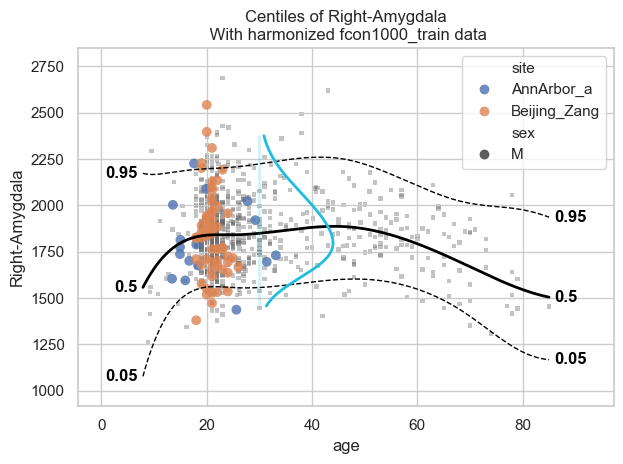

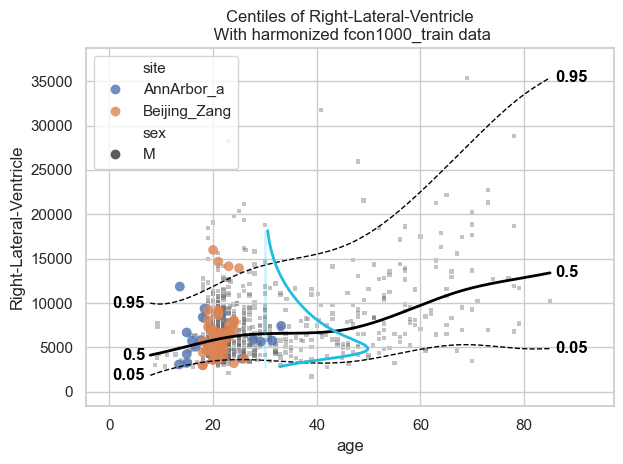

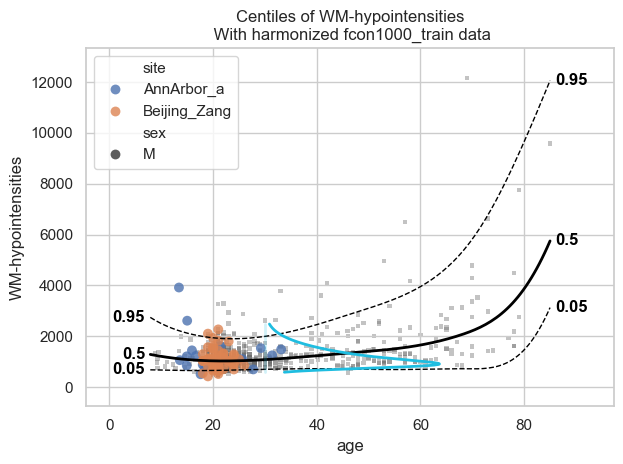

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>]

In [22]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot these centiles, the default is [0.05, 0.25, 0.5, 0.75, 0.95]
    scatter_data=train_s4,  # Scatter this data along with the centiles
    batch_effects={"site": ["Beijing_Zang", "AnnArbor_a"], "sex": ["M"]},  # Highlight these groups
    show_other_data=True,  # scatter data not in those groups as smaller black circles
    harmonize=True,  # harmonize the scatterdata, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
    conditionals=[30]
)

We can also split the QQ plots by batch effects:

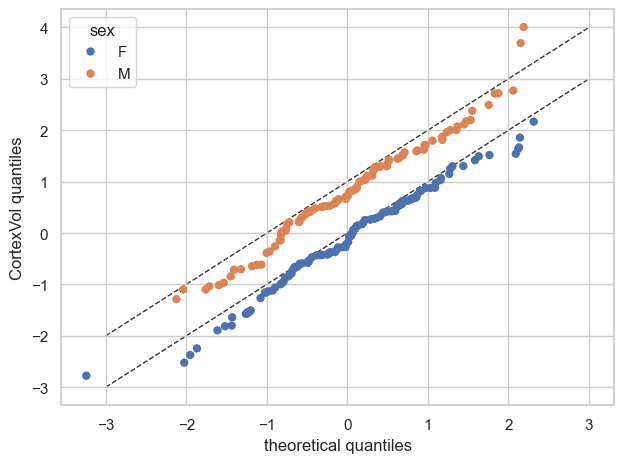

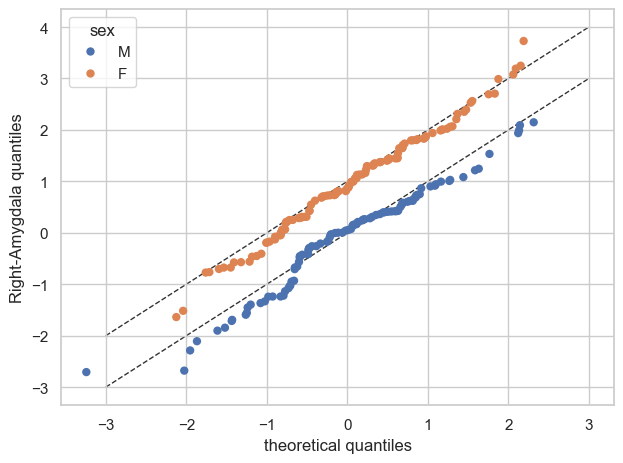

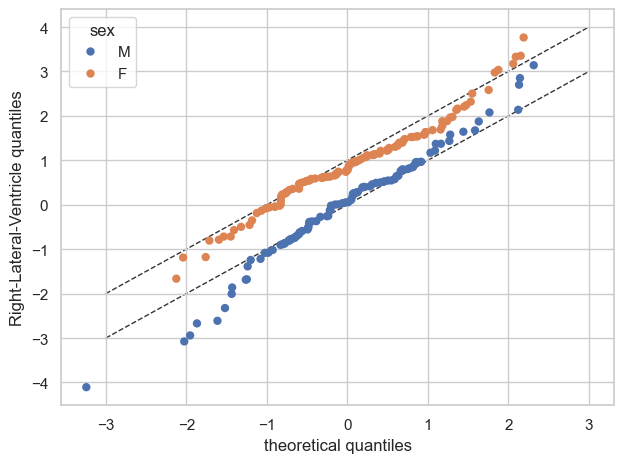

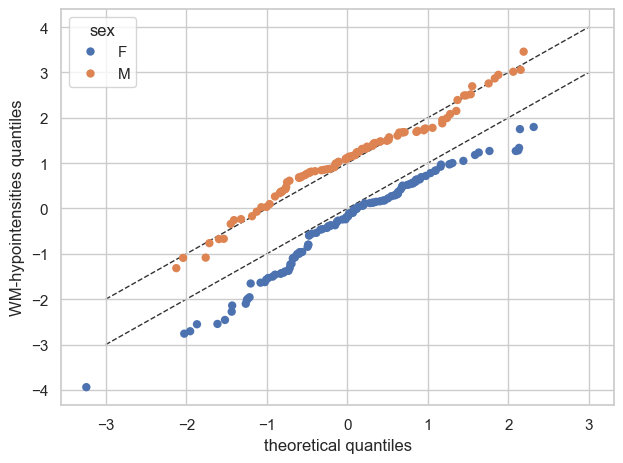

In [23]:
plot_qq(test_s4, plot_id_line=True, hue_data="sex", split_data="sex")
sns.set_theme(style="darkgrid", rc={"axes.facecolor": (0, 0, 0, 0)})

And finally the ridge plot:

c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
c:\Users\kontsi\AppData\Local\anaconda3\envs\.ptk-dev\Lib\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large en

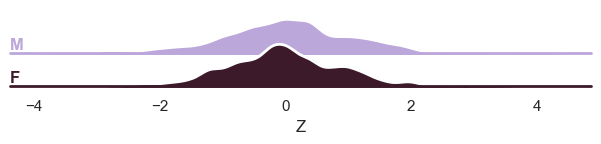

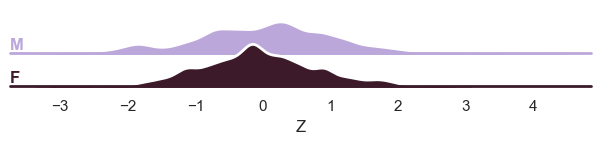

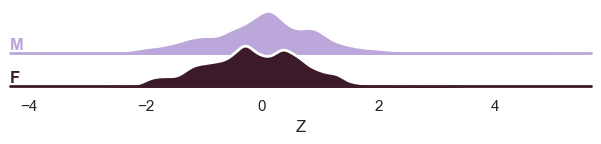

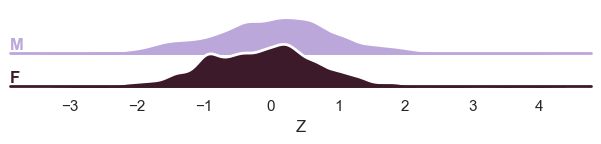

[<Figure size 750x100 with 2 Axes>,
 <Figure size 750x100 with 2 Axes>,
 <Figure size 750x100 with 2 Axes>,
 <Figure size 750x100 with 2 Axes>]

In [24]:
plot_ridge(
    train_s4, "Z", split_by="sex"
)  # We can also show the 'Y' variable, and that will show the marginal distribution of the response variable, per batch effect.

Evaluation statistcs are stored in the NormData object:

## Step 6: What's next?

Now we have a normative hierarchical Bayesian regression model, we can use it to:

- Make predictions on new data
- Harmonize data, this means that we 'remove' the batch effects from the data, by simulating what the data would have looked like if all data was from the same batch.
- Synthesize new data
- Extend the model using data from new batches

### 6.1 Predicting

You can also make predictions for a new data set:

In [25]:
model.predict(test)

<xarray.NormData> Size: 105kB
Dimensions:            (observations: 216, response_vars: 4, covariates: 1,
                        batch_effect_dims: 2, centile: 5, statistic: 13)
Coordinates:
  * observations       (observations) int64 2kB 756 769 692 616 ... 751 470 1043
  * response_vars      (response_vars) <U23 368B 'WM-hypointensities' ... 'Co...
  * covariates         (covariates) <U3 12B 'age'
  * batch_effect_dims  (batch_effect_dims) <U4 32B 'sex' 'site'
  * centile            (centile) float64 40B 0.05 0.25 0.5 0.75 0.95
  * statistic          (statistic) <U8 416B 'EXPV' 'Kurtosis' ... 'Skewness'
Data variables:
    subject_ids        (observations) object 2kB 'Munchen_sub96752' ... 'Quee...
    Y                  (observations, response_vars) float64 7kB 2.721e+03 .....
    X                  (observations, covariates) float64 2kB 63.0 ... 23.0
    batch_effects      (observations, batch_effect_dims) <U17 29kB 'F' ... 'Q...
    Z                  (observations, response_vars) float64 7kB 0.52 ... -1.144
    centiles           (centile, observations, response_vars) float64 35kB 1....
    baseline_logp      (observations, response_vars) float64 7kB -3.66 ... -0...
    logp               (observations, response_vars) float64 7kB -1.619 ... -...
    Yhat               (observations, response_vars) float64 7kB 2.365e+03 .....
    statistics         (response_vars, statistic) float64 416B 0.3925 ... -0....
Attributes:
    real_ids:                       True
    is_scaled:                      False
    name:                           fcon1000_test
    unique_batch_effects:           {np.str_('sex'): ['M', 'F'], np.str_('sit...
    batch_effect_counts:            defaultdict(<function NormData.register_b...
    covariate_ranges:               {np.str_('age'): {'min': 7.88, 'max': 85.0}}
    batch_effect_covariate_ranges:  {np.str_('sex'): {'M': {np.str_('age'): {...

### 6.2 Harmonize

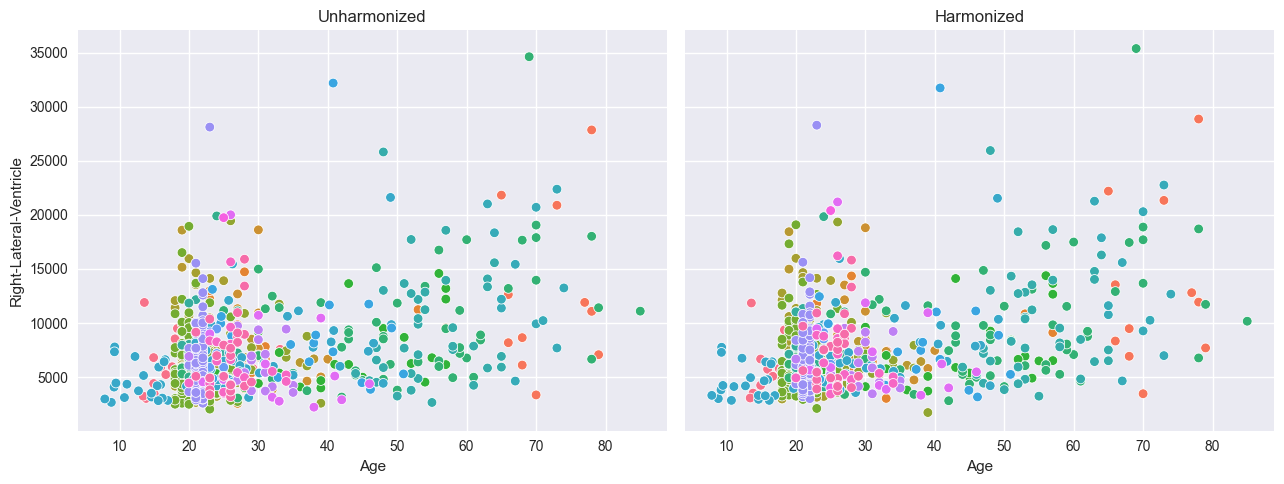

In [ ]:
reference_batch_effect = {
    "site": "Beijing_Zang",
    "sex": "M",
}  # Set a pseudo-batch effect. I.e., this means 'pretend that all data was from this site and sex'

model.harmonize(train_s4, reference_batch_effect=reference_batch_effect) 

plt.style.use("seaborn-v0_8")
df = train_s4.to_dataframe()
fig, ax = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
sns.scatterplot(data=df, x=("X", "age"), y=("Y", feature_to_plot), hue=("batch_effects", "site"), ax=ax[0])
sns.scatterplot(data=df, x=("X", "age"), y=("Y_harmonized", feature_to_plot), hue=("batch_effects", "site"), ax=ax[1])
ax[0].title.set_text("Unharmonized")
ax[1].title.set_text("Harmonized")
ax[0].legend([], [])
ax[1].legend([], [])
ax[0].set_xlabel("Age")
ax[0].set_ylabel(feature_to_plot)
ax[1].set_xlabel("Age")
ax[1].set_ylabel(feature_to_plot)
plt.tight_layout()
plt.show()

### 6.3 Synthesize

Our models can synthesize new data that follows the learned distribution. 

Not only the distribution of the response variables given a covariate is learned, but also the ranges of the covariates _within_ each batch effect. So if we have fitted a model on a number of sites, and subjects from A have an age between 10 and 20, then the synthesized pseudo-subjects from site A will also have an age between 10 and 20.

Not only that, but we also sample the batch effects in the frequency of the batch effects in the original data. So if the train data contained twice as many subjects from site A as site B, then the synthesized pseudo-subjects will also have twice as many subjects from site A as site B.

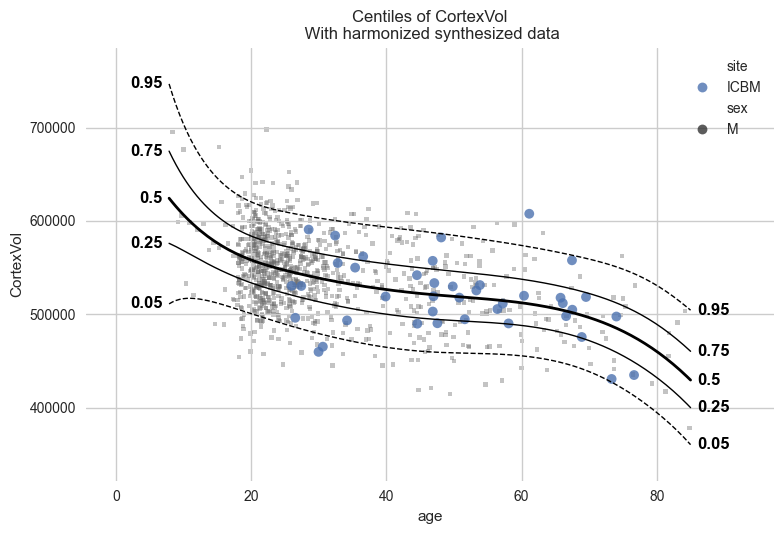

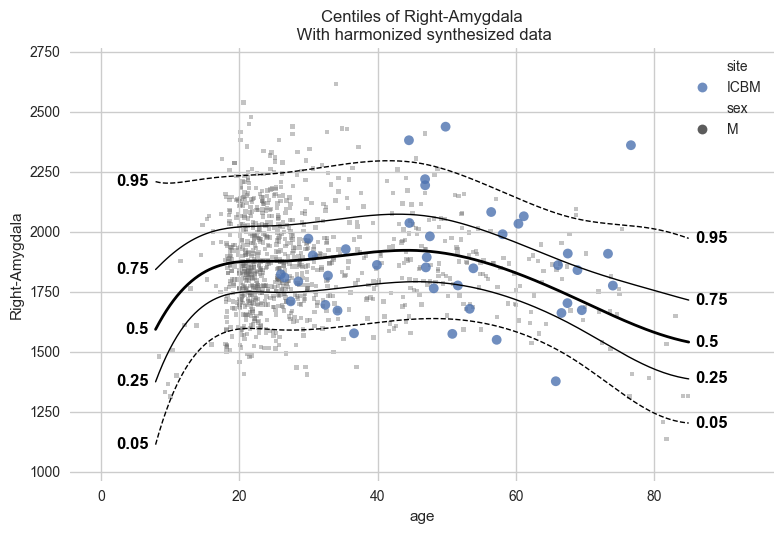

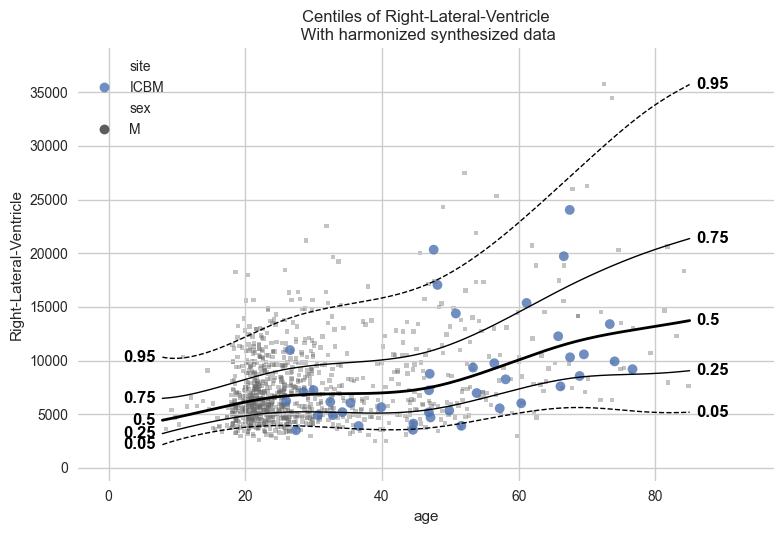

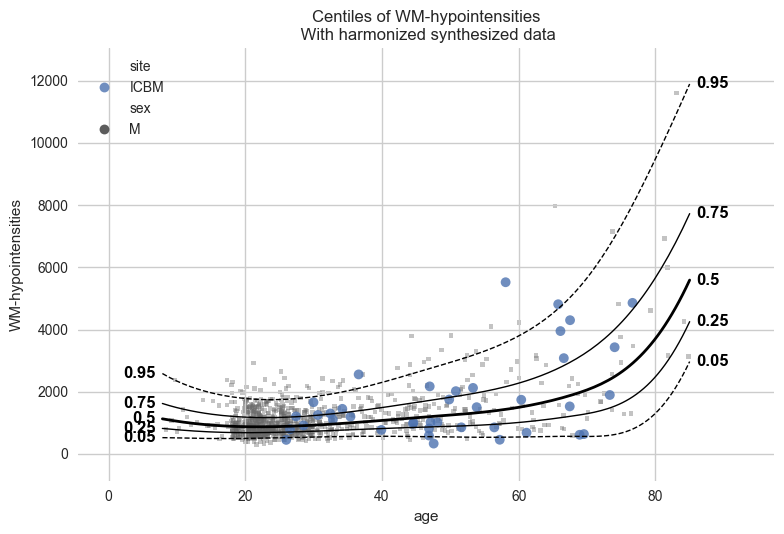

[<Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>]

In [31]:
# Generate 10000 synthetic datapoints from scratch
synthetic_data = model.synthesize(covariate_range_per_batch_effect=True, n_samples=1000)
# Show the synthetic data along with the centiles
plot_centiles_advanced(
    model,
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic_data,
    show_other_data=True
)

In [33]:
# Synthesize new Y data for existing X data
new_test_data = test.copy()

# Remove the Y data, this way we will synthesize new Y data for the existing X data
if hasattr(new_test_data, "Y"):
    del new_test_data["Y"]

synthetic = model.synthesize(new_test_data)  # <- will fill in the missing Y data

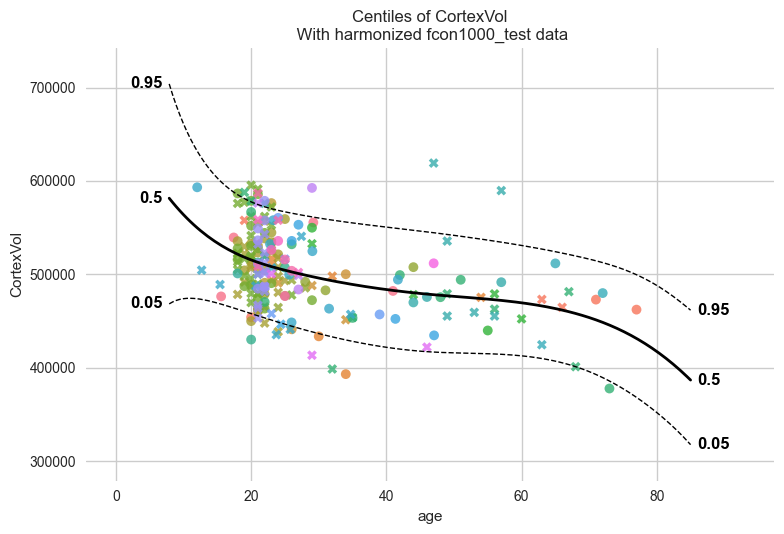

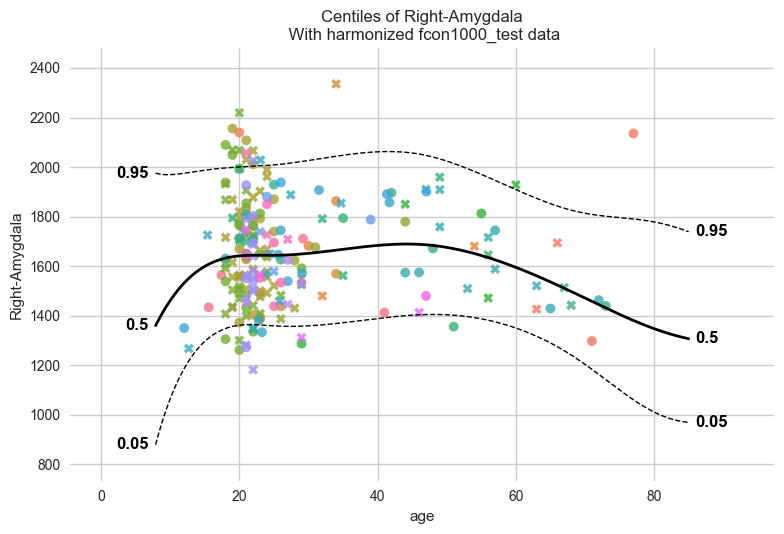

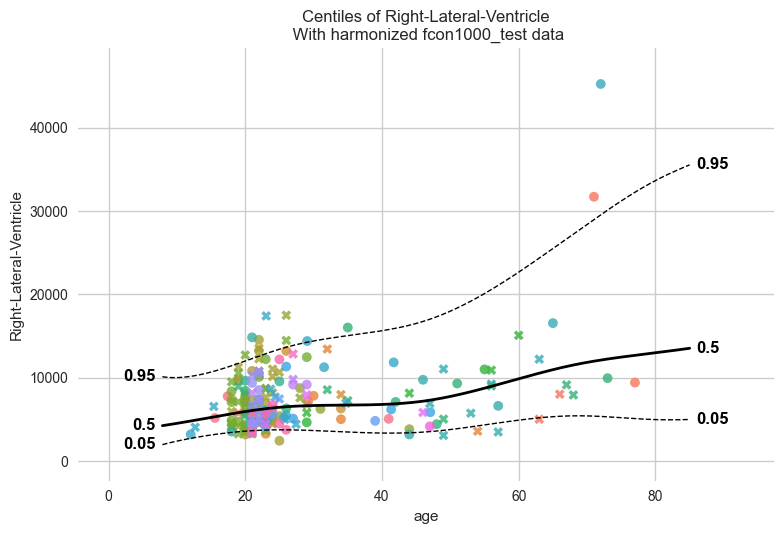

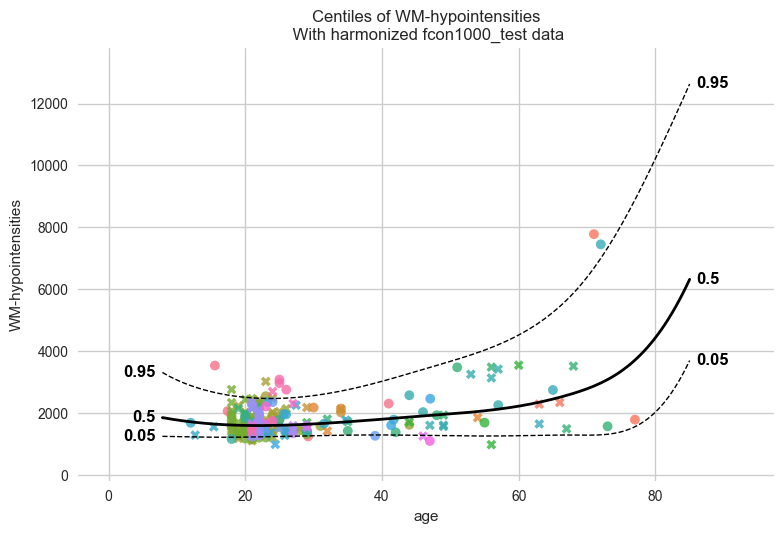

[<Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>,
 <Figure size 800x550 with 1 Axes>]

In [34]:
plot_centiles_advanced(
    model,
    centiles=[0.05, 0.5, 0.95],  # Plot arbitrary centiles
    covariate="age",  # Which covariate to plot on the x-axis
    scatter_data=synthetic,  # Scatter the train data points
    batch_effects="all",  # You can set this to "all" to show all batch effects
    show_other_data=False,  # Show data points that do not match any batch effects
    show_centile_labels=True,
    harmonize_data=True,  # Set this to False to see the difference
    show_legend=False,  # Don't show the legend because it crowds the plot
)

## Next steps

Please see the other tutorials for more examples, and we also recommend you to read the documentation! As this toolkit is still in development, the documentation may not be up to date. If you find any issues, please let us know! 

Also, feel free to contact us on Github if you have any questions or suggestions.

Have fun modeling!

### Bonus content

Here is another model configuration using a SHASH likelihood, but this one also has a linear regression in epsilon and delta. If you have a feature that is heavily skewed and for which the skewness also changes with the covariates, this is the model for you:

In [35]:
# Here's a model with a SHASHb likelihood, with a linear regression in all four parameters, so including epsilon and delta.
# This is a very flexible model, but it will also take a lot longer to run.
mu = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 10.0)),
    intercept=make_prior(
        random=True,
        mu=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
        sigma=make_prior(dist_name="Gamma", dist_params=(3.0, 1.0)),
    ),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)
sigma = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 2.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(0.0, 3.0),
)

epsilon = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
)

delta = make_prior(
    linear=True,
    slope=make_prior(dist_name="Normal", dist_params=(0.0, 1.0)),
    intercept=make_prior(dist_name="Normal", dist_params=(1.0, 1.0)),
    basis_function=BsplineBasisFunction(basis_column=0, nknots=5, degree=3),
    mapping="softplus",
    mapping_params=(
        0.0,
        3.0,  # Scale for smoothness
        0.6,  # We need to provide a vertical shift as well, because the SHASH mapping goes a bit wild with low values for delta
    ),
)

shashb2_regression_model = HBR(
    name="template",
    cores=16,
    progressbar=True,
    draws=1500,
    tune=500,
    chains=4,
    nuts_sampler="nutpie",
    likelihood=SHASHbLikelihood(mu, sigma, epsilon, delta),
)